In [1]:
%matplotlib widget

import os
import mne
import tqdm
import pytz
import edfio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mne.set_log_level('error')
from tqdm import tqdm
from pathlib import Path
from mne.io import concatenate_raws, read_raw_edf
from edf2parquet.readers import ParquetReader
from edf2parquet.converters import EdfToParquetConverter, AdvancedEdfToParquetConverter

from bscarlos.settings import RAW_KISPI_DATA_FOLDER
from bscarlos.settings import PROCESSED_KISPI_DATA_FOLDER


# ETL
Here we explore the extracted the raw data (.edf) from KISPI patients and their corresponding annotations (.txt) from our `RAW_KISPI_DATA_FOLDER`.

We preprocess and filter the raw data using `mne` as we want make sure we filter the full/raw data before performing any transformations.  

We transform the data into more managable `pandas.dataframes` with the goal to combine the annotations which are our 'ground_truth' labels.

In the end we should have a dataframe for each patients containing 6-bipolar channel columns and 1-ground truth column.

We load/export our newly merged dataframes stored as `.parquet` files accomanied with a `data_attributes.csv` file into our `PROCESSED_KISPI_DATA_FOLDER`.  


### Filter .edf files

 We use the popular MNE<sup>1</sup> python library to conduct our filtering.

 [1] [MNE Documentation](https://mne.tools/stable/index.html) 

In [2]:
data_files_a1 = sorted(list(RAW_KISPI_DATA_FOLDER.glob('*annotated1.edf')))
data_files_a2 = sorted(list(RAW_KISPI_DATA_FOLDER.glob('*annotated2.edf')))
print(data_files_a1)
print(data_files_a2)

[WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE008_annotated1.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE021_annotated1.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE026_annotated1.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE038_annotated1.edf')]
[WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE008_annotated2.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE021_annotated2.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/raw_kispi/SE026_annotated2.edf'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Bu

#### Filter a1 files

Converting EDF to MNE.Raw-object:   0%|          | 0/4 [00:00<?, ?it/s]

Dropped channels: ['EEG F3', 'EEG Fz', 'EEG F4', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG A1', 'EEG A2', 'EKG', 'PHO', 'EOG', 'EMG']


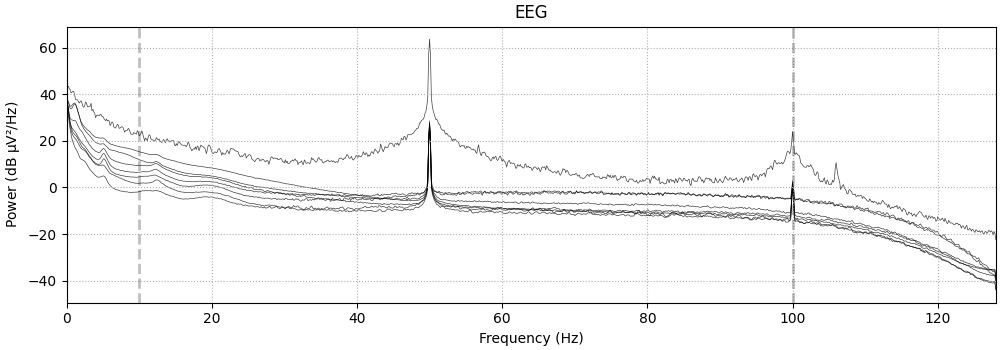

Figure(1000x350)


c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1112: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


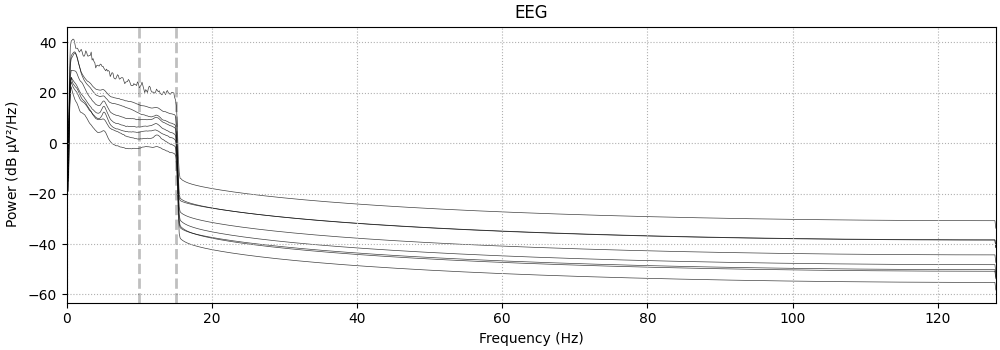

Figure(1000x350)


Converting EDF to MNE.Raw-object:  25%|██▌       | 1/4 [00:33<01:41, 33.69s/it]

Processed and saved: C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE008_annotated1_filtered.edf
Dropped channels: ['EEG F3', 'EEG Fz', 'EEG F4', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG A1', 'EEG A2', 'NASE', 'EKG', 'PHO']


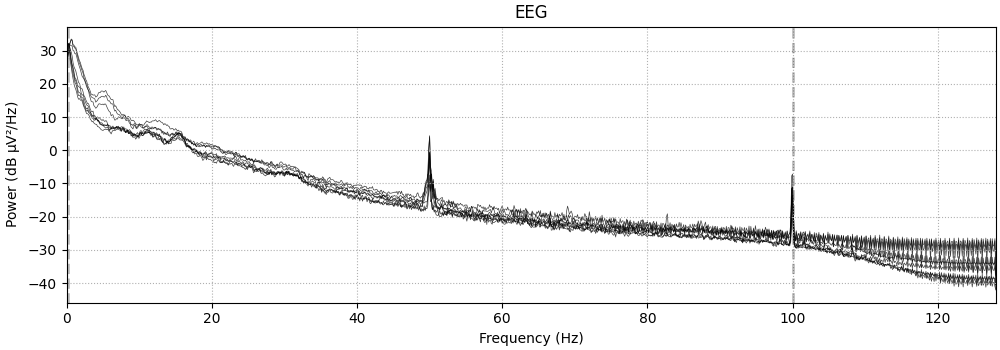

Figure(1000x350)


c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1112: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


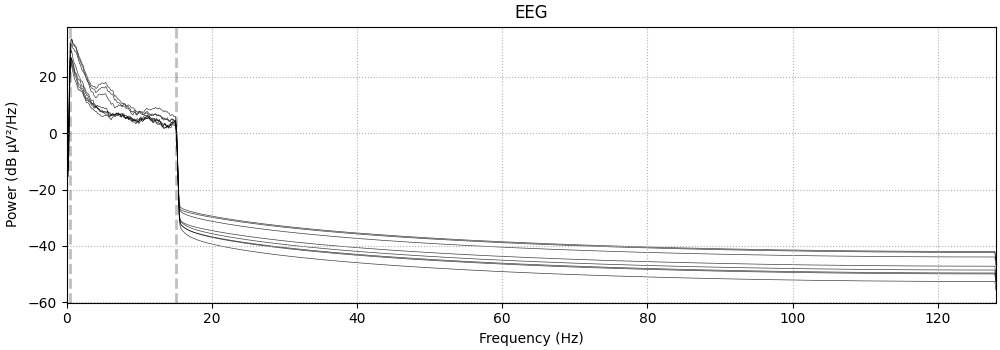

Converting EDF to MNE.Raw-object:  50%|█████     | 2/4 [00:34<00:28, 14.46s/it]

Figure(1000x350)
Processed and saved: C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE021_annotated1_filtered.edf
Dropped channels: ['EEG F3', 'EEG Fz', 'EEG F4', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG A1', 'EEG A2', 'NASE', 'EKG', 'PHO']


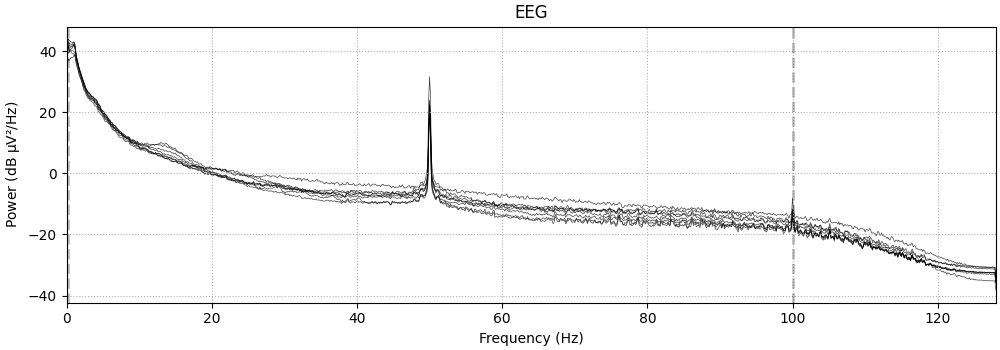

Figure(1000x350)


c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1112: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


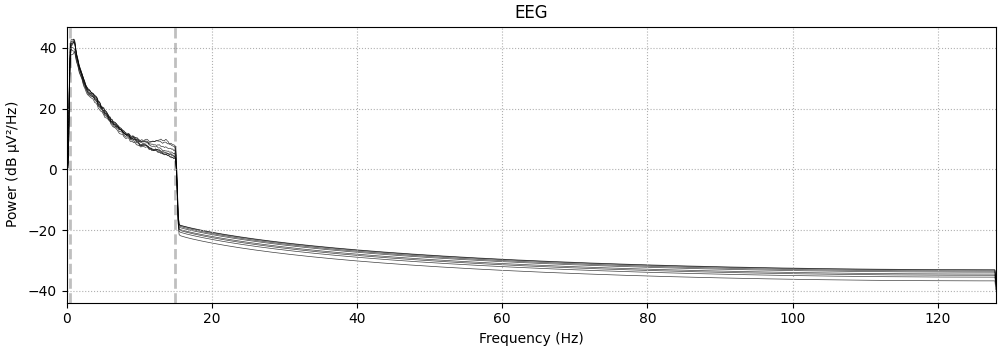

Converting EDF to MNE.Raw-object:  75%|███████▌  | 3/4 [00:36<00:08,  8.71s/it]

Figure(1000x350)
Processed and saved: C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE026_annotated1_filtered.edf
Dropped channels: ['EEG F3', 'EEG Fz', 'EEG F4', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG A1', 'EEG A2', 'NASE', 'EKG', 'PHO']


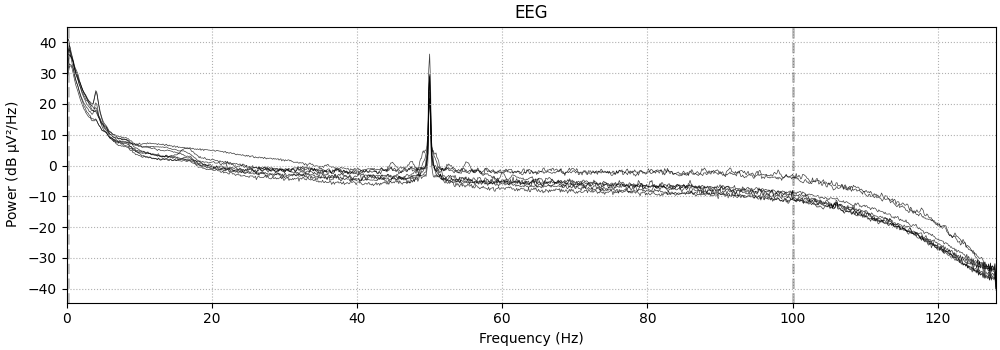

Figure(1000x350)


c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1112: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


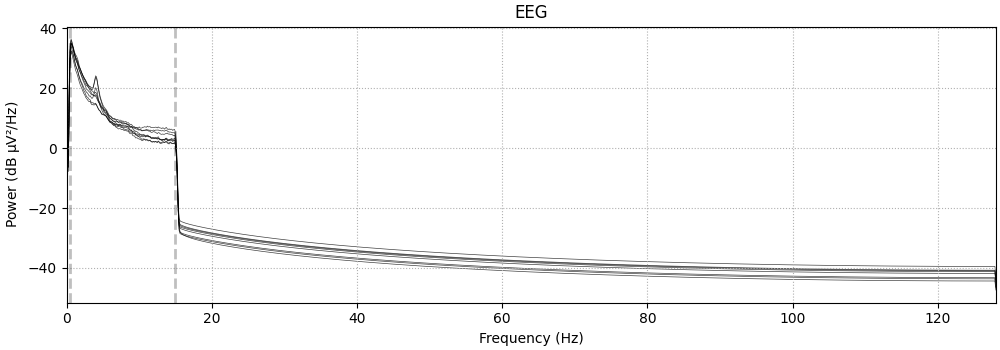

Figure(1000x350)


Converting EDF to MNE.Raw-object: 100%|██████████| 4/4 [00:39<00:00,  9.88s/it]

Processed and saved: C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE038_annotated1_filtered.edf


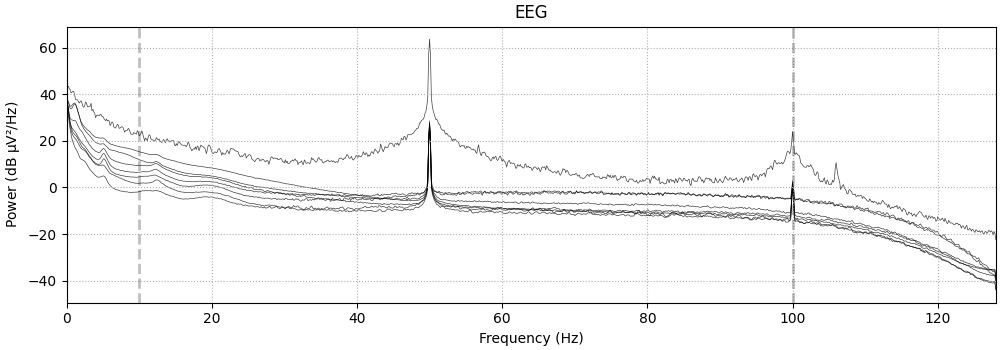

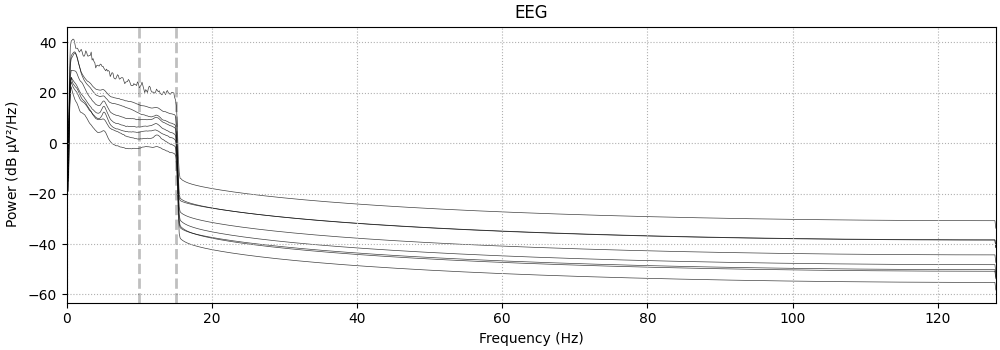

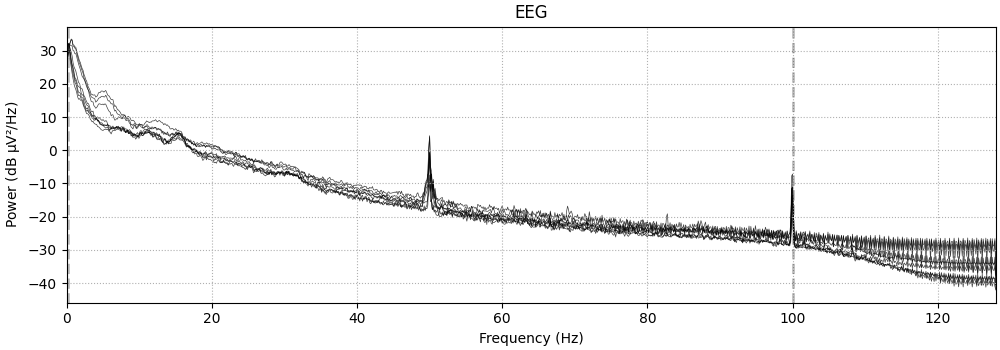

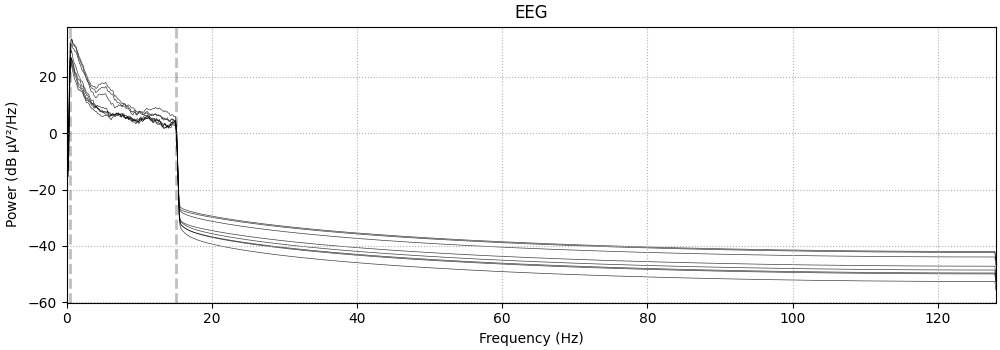

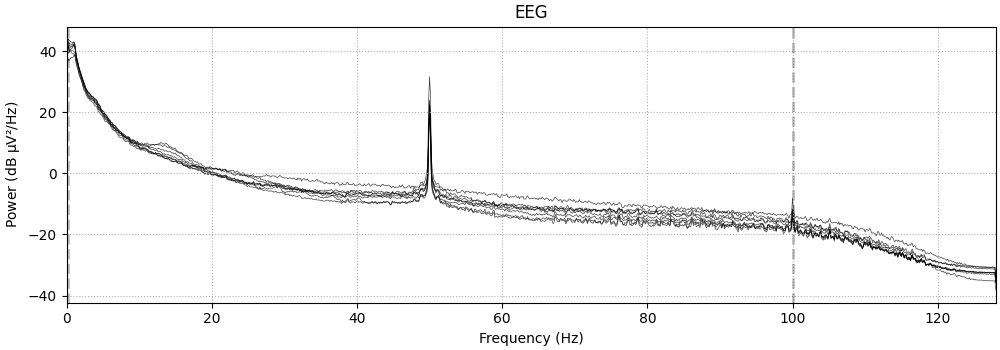

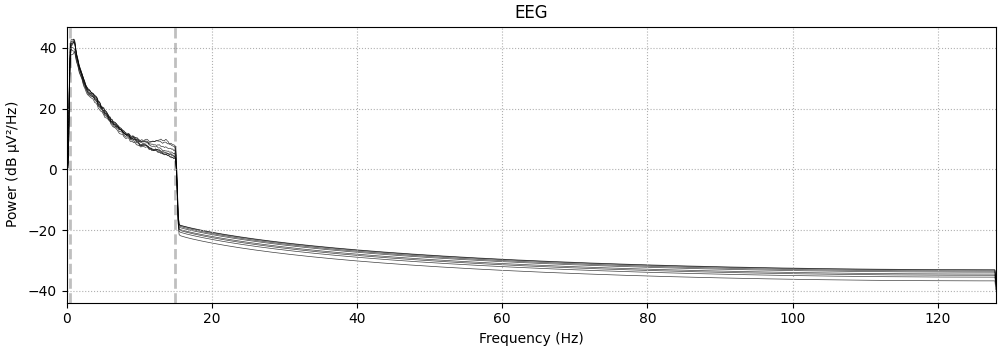

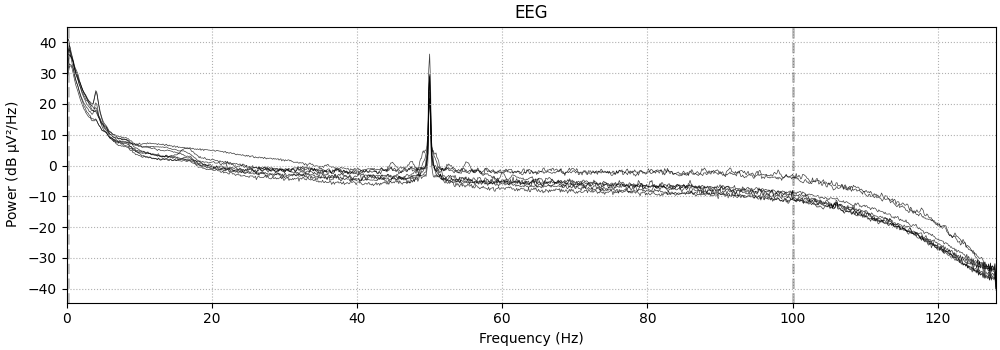

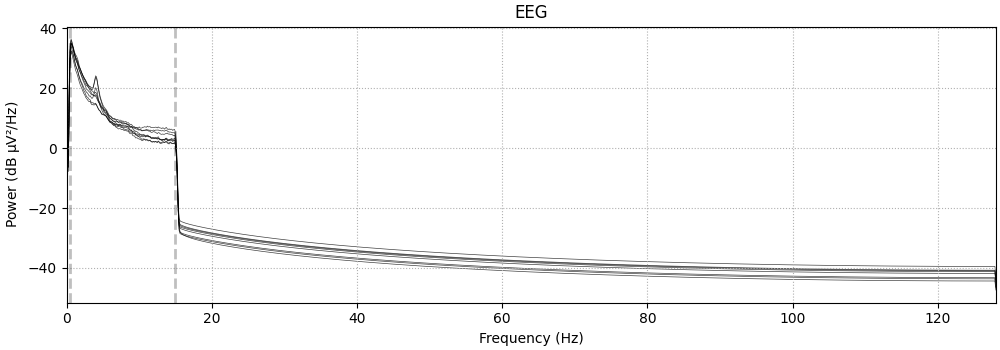

In [3]:
for filename in tqdm(data_files_a1, desc='Converting EDF to MNE.Raw-object'):
    try:
        # Load the EDF file as a Raw object
        raw = mne.io.read_raw_edf(filename, preload=True)

        # Channels to attempt to drop
        channels_to_remove = ['EEG F3','EEG Fz','EEG F4',
                              'EEG C3','EEG Cz','EEG C4',
                              'EEG P3','EEG Pz','EEG P4',
                              'EEG O1','EEG O2','EEG A1','EEG A2',
                              'NASE','EKG','PHO', 'EOG', 'EMG']

        # Find the channels that exist in the file
        existing_channels = [ch for ch in channels_to_remove if ch in raw.ch_names]

        if existing_channels:
            raw.drop_channels(existing_channels)
            print(f"Dropped channels: {existing_channels}")
        else:
            print(f"No matching channels to drop in {filename}")

        # Plot the PSD before filtering
        print(raw.compute_psd().plot())

        # Apply a band-pass filter (e.g., 0.5 to 15 Hz)
        low_cut = 0.5
        hi_cut = 15
        iir_params = dict(order=18, ftype='cheby1', rp=0.1, rs=None, output='sos')
        raw.filter(low_cut, hi_cut, method='iir', iir_params=iir_params)

        # Plot the PSD after filtering
        print(raw.compute_psd().plot())

        # Save the filtered Raw object to a new file
        filename_path = Path(filename)  # Convert to Path object
        output_filename = filename_path.with_name(filename_path.stem + '_filtered.edf')
        mne.export.export_raw(output_filename, raw, fmt='edf',overwrite=True)

        print(f"Processed and saved: {output_filename}")

    except Exception as e:
        print(f"Failed to process {filename}: {e}")

#### Filter a2 files

Converting EDF to MNE.Raw-object:   0%|          | 0/4 [00:00<?, ?it/s]

C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE008_annotated2.edf
--------------------
Dropped channels: ['EEG F3', 'EEG Fz', 'EEG F4', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG A1', 'EEG A2', 'EKG', 'PHO', 'EOG', 'EMG']


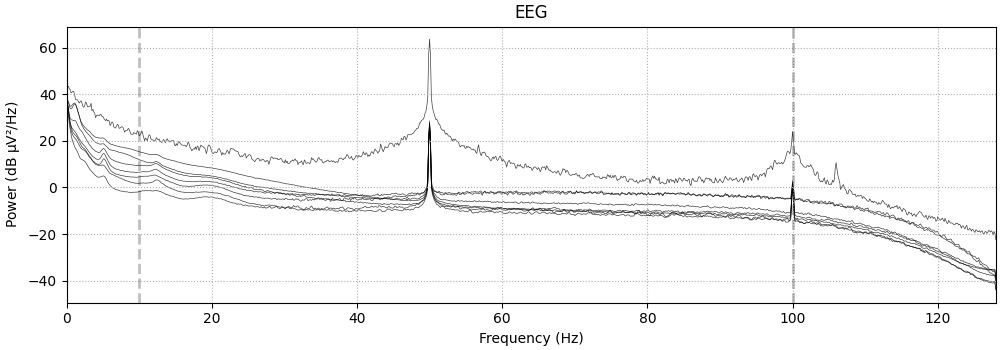

Figure(1000x350)


c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1112: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


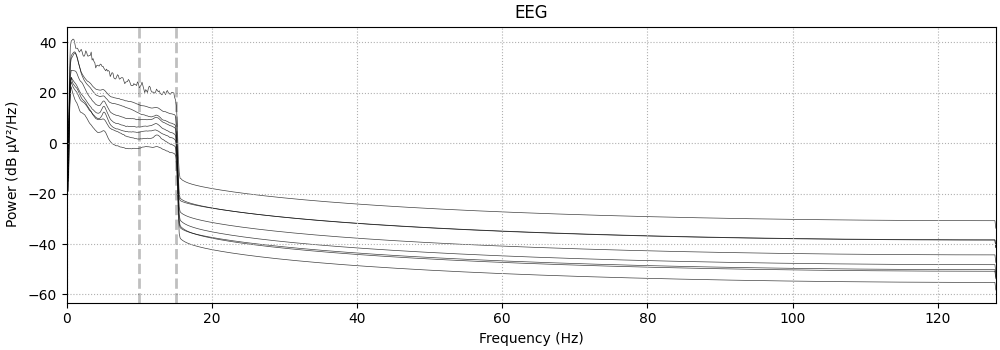

Figure(1000x350)


Converting EDF to MNE.Raw-object:  25%|██▌       | 1/4 [00:22<01:07, 22.33s/it]

Processed and saved: C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE008_annotated2_filtered.edf
C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE021_annotated2.edf
--------------------
Dropped channels: ['EEG F3', 'EEG Fz', 'EEG F4', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG A1', 'EEG A2', 'NASE', 'EKG', 'PHO']


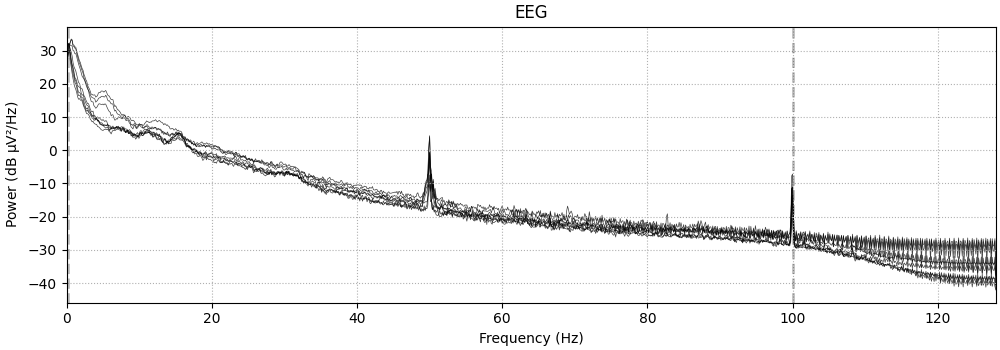

Figure(1000x350)


c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1112: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


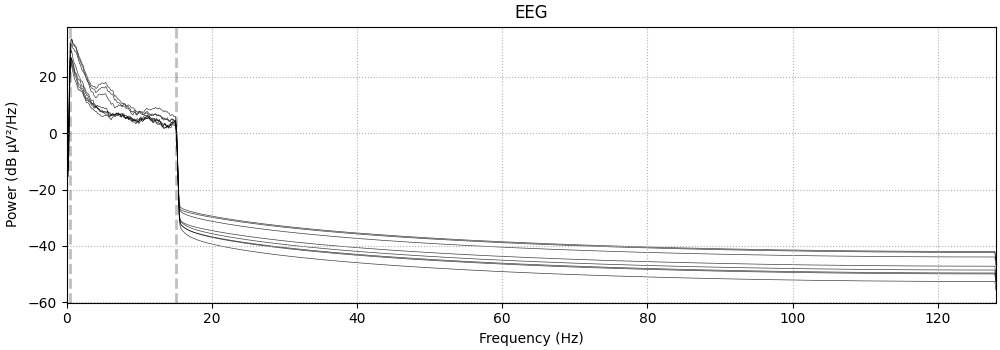

Converting EDF to MNE.Raw-object:  50%|█████     | 2/4 [00:23<00:19,  9.77s/it]

Figure(1000x350)
Processed and saved: C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE021_annotated2_filtered.edf
C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE026_annotated2.edf
--------------------
Dropped channels: ['EEG F3', 'EEG Fz', 'EEG F4', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG A1', 'EEG A2', 'NASE', 'EKG', 'PHO']


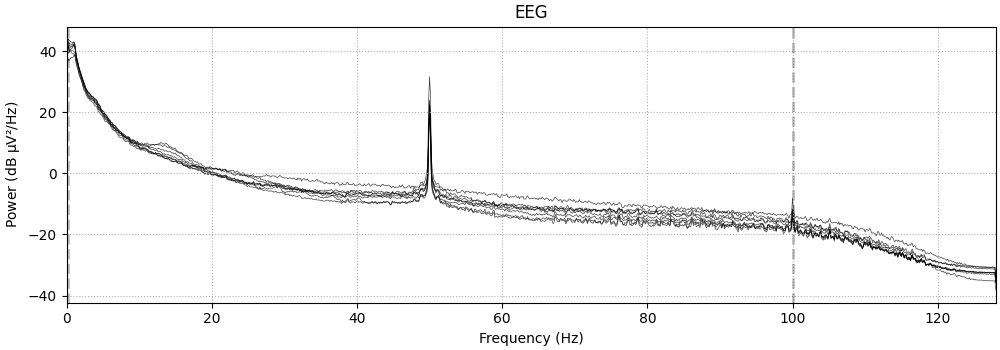

Figure(1000x350)


c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1112: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


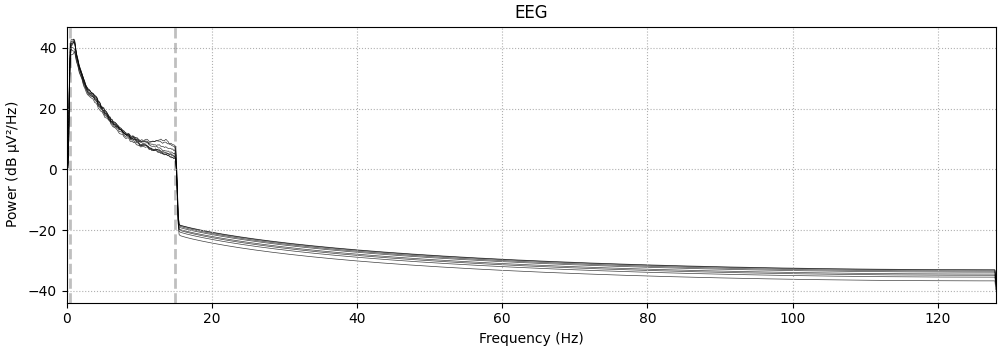

Converting EDF to MNE.Raw-object:  75%|███████▌  | 3/4 [00:25<00:06,  6.12s/it]

Figure(1000x350)
Processed and saved: C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE026_annotated2_filtered.edf
C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE038_annotated2.edf
--------------------
Dropped channels: ['EEG F3', 'EEG Fz', 'EEG F4', 'EEG C3', 'EEG Cz', 'EEG C4', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG A1', 'EEG A2', 'NASE', 'EKG', 'PHO']


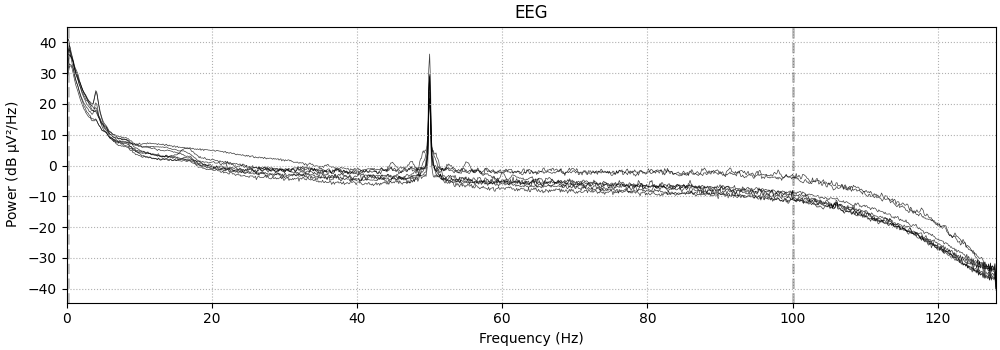

Figure(1000x350)


c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\scipy\signal\_filter_design.py:1112: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


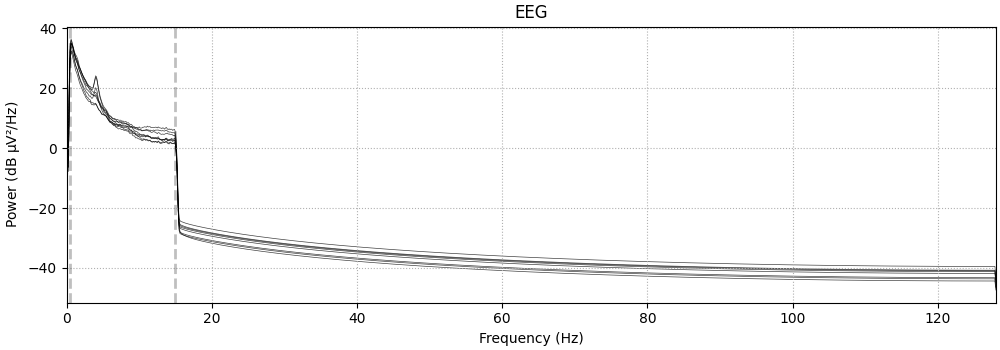

Figure(1000x350)


Converting EDF to MNE.Raw-object: 100%|██████████| 4/4 [00:27<00:00,  6.96s/it]

Processed and saved: C:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\data\raw_kispi\SE038_annotated2_filtered.edf


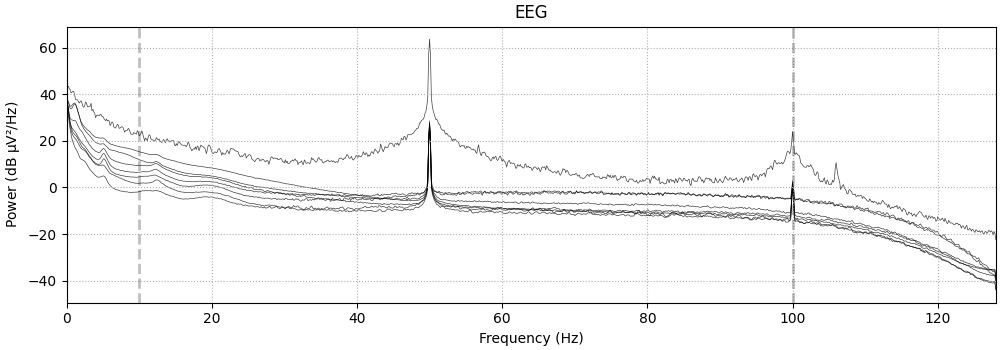

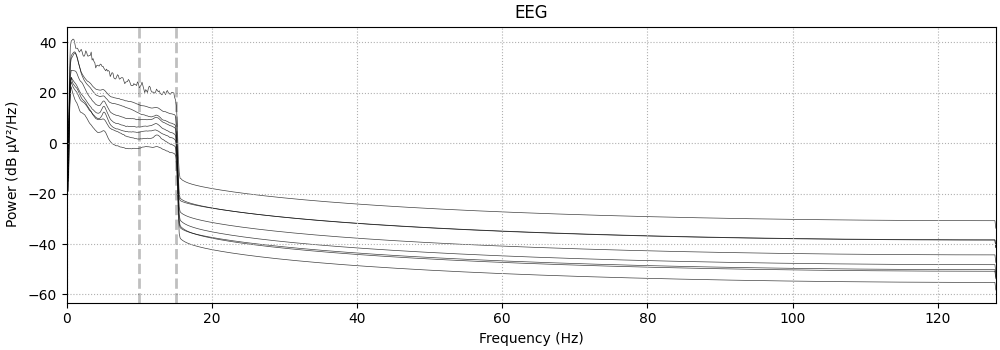

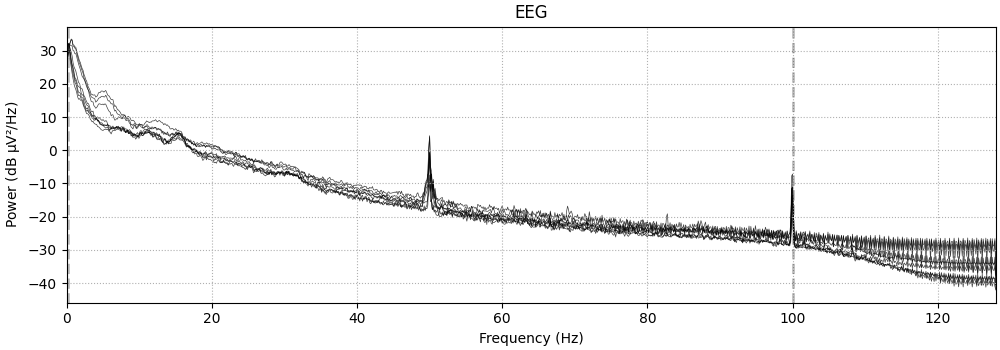

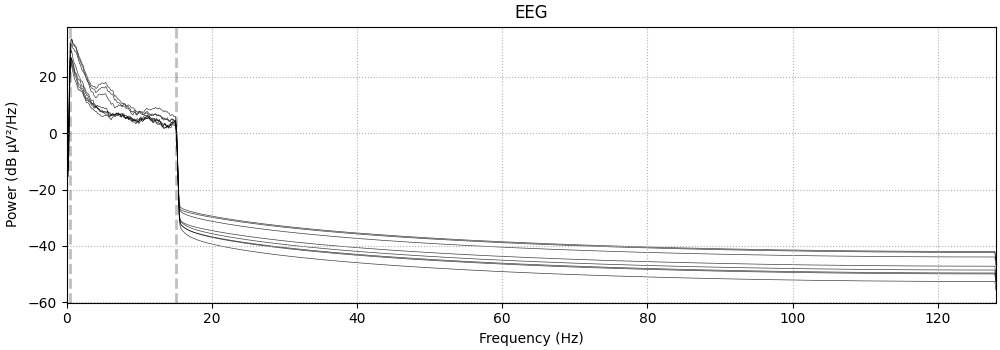

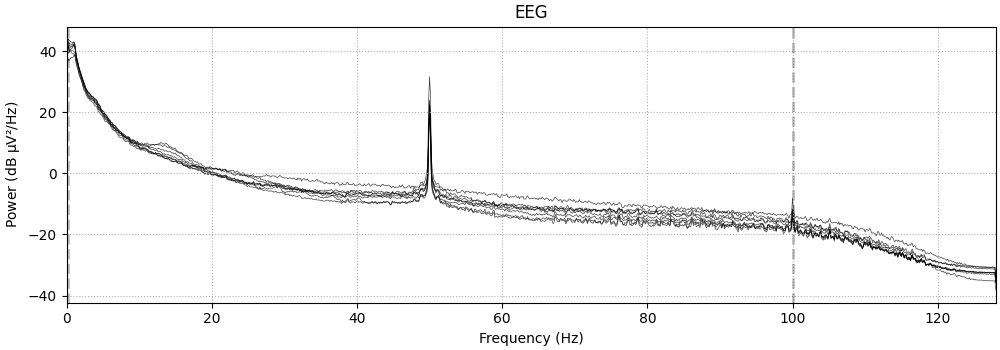

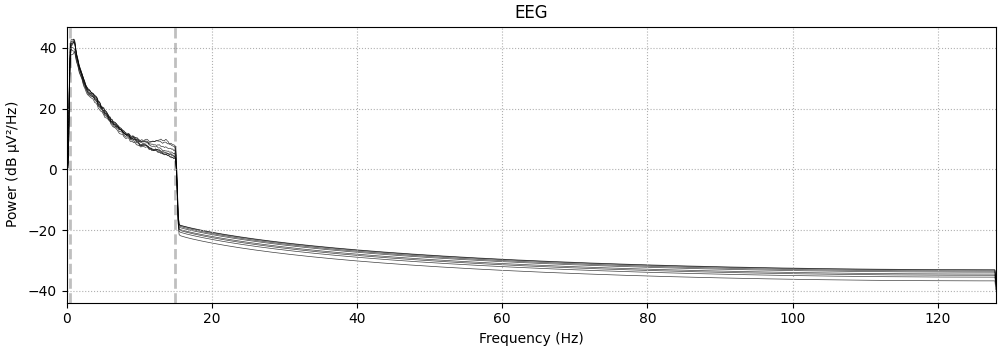

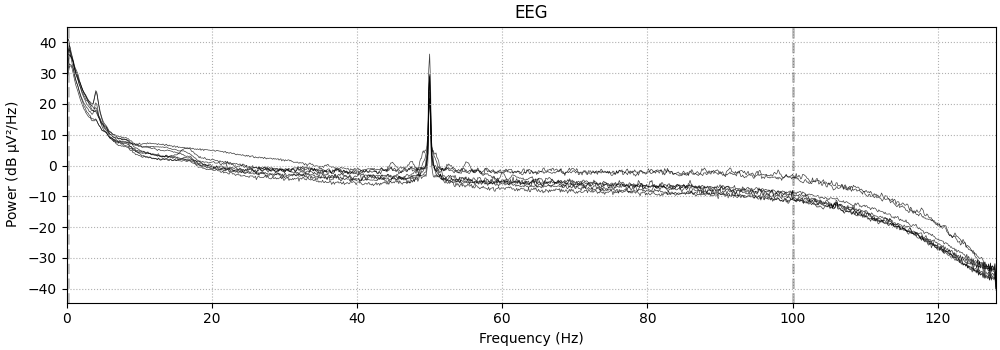

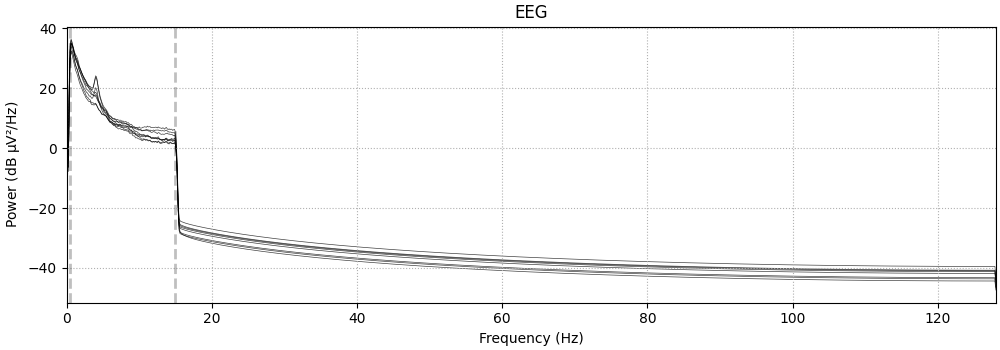

In [4]:
for filename in tqdm(data_files_a2, desc='Converting EDF to MNE.Raw-object'):
    print(filename)
    print('-'*20)
    try:
        # Load the EDF file as a Raw object
        raw = mne.io.read_raw_edf(filename, preload=True)

        # Channels to attempt to drop
        channels_to_remove = ['EEG F3','EEG Fz','EEG F4',
                              'EEG C3','EEG Cz','EEG C4',
                              'EEG P3','EEG Pz','EEG P4',
                              'EEG O1','EEG O2','EEG A1','EEG A2',
                              'NASE','EKG','PHO', 'EOG', 'EMG']

        # Find the channels that exist in the file
        existing_channels = [ch for ch in channels_to_remove if ch in raw.ch_names]

        if existing_channels:
            raw.drop_channels(existing_channels)
            print(f"Dropped channels: {existing_channels}")
        else:
            print(f"No matching channels to drop in {filename}")

        # Plot the PSD before filtering
        print(raw.compute_psd().plot())

        # Apply a band-pass filter (e.g., 0.5 to 15 Hz)
        low_cut = 0.5
        hi_cut = 15
        iir_params = dict(order=18, ftype='cheby1', rp=0.1, rs=None, output='sos')
        raw.filter(low_cut, hi_cut, method='iir', iir_params=iir_params)

        # Plot the PSD after filtering
        print(raw.compute_psd().plot())

        # Save the filtered Raw object to a new file
        filename_path = Path(filename)  # Convert to Path object
        output_filename = filename_path.with_name(filename_path.stem + '_filtered.edf')
        mne.export.export_raw(output_filename, raw, fmt='edf', overwrite=True)

        print(f"Processed and saved: {output_filename}")

    except Exception as e:
        print(f"Failed to process {filename}: {e}")

### Convert .edf to parquet files
In order to better handle the dataset it would be advantagous to create a dataframe using trusty `pandas`, however we first needed to convert our EEG files from .edf format into parquet files.

To accomplish this we used the `edf2parquet` a simple utility package to convert EDF/EDF+ files into Apache Parquet format while preserving the EDF file header information and signal headers metadata information then we will be able to read the files directly<sup>2</sup>. 

We specifically used the built-in `AdvancedEdfToParquetConverter` class to convert the files and utilize the `exclude_singals` argument to exclude the following list of signals:

 ["EEG Fz", "EEG F3", "EEG F4" "EEG C3", "EEG Cz", "EEG C4", "EEG P3", "EEG Pz", 
 "EEG P4", "EEG O1", "EEG O2", "EEG A1", "EEG A2", "EKG", "EOG", "EMG", "PHO", "NASE"]  

In addition we create a data_attributes.csv file with all the important attributes we unvail.

---


[2] [edf2parquet repository](https://github.com/NarayanSchuetz/edf2parquet/tree/main)

This is just a quick test of the converter uncomment `#test_converter.convert()` to produce output.

In [5]:
test_edf_file = str(RAW_KISPI_DATA_FOLDER / Path("SE008_120418U-A.edf"))
test_parquet_output_dir = RAW_KISPI_DATA_FOLDER

test_converter = AdvancedEdfToParquetConverter(edf_file_path=test_edf_file,  # path to the EDF file
                                          # excluded signals     
                                          exclude_signals=["Audio"],  
                                          # output directory path
                                          parquet_output_dir=test_parquet_output_dir,
                                          # grouping signals with same sampling frequency
                                          group_by_sampling_freq=True,  
                                          # add a pd.DatetimeIndex to the resulting parquet files
                                          datetime_index=True,
                                          # specifies timezone location and start_date of the EDF file
                                          local_timezone=(pytz.timezone("Europe/Zurich"), pytz.timezone("Europe/Zurich")),
                                          # compression codec
                                          compression_codec="GZIP" 
                                          )

#test_converter.convert()

### Correct .edf header 'subject code' and 'admincode' for all annotated data files
Reason for this is that it causes issues when creating the data_attributes.csv file

- [x] This was completed manually using `EDFBrowser`'s Tools -> "Header editor repair" 

## Extract
We extract the files we want from our `RAW_KISPI_DATA_FOLDER` and save them into a list `filenames`

We will keep to list `filenames_a1` for our annotations from annotator1 and `filenames_a2` for our annotations from annotator2.

That way we avoid cross contamination of ground truth labels which could potentially ruin our end inter-rater agreement analysis.

We only make the list `filenames` containing all files to produce our `data_attributes.csv` file later.

In [6]:
# define the input and output folders
input_folder = RAW_KISPI_DATA_FOLDER
output_folder = PROCESSED_KISPI_DATA_FOLDER

# create the output folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# get a list of all .edf files in the input folder
filenames_a1 = [filename for filename in os.listdir(input_folder) if filename.__contains__("annotated1_filtered") and filename.endswith('.edf')]
filenames_a2 = [filename for filename in os.listdir(input_folder) if filename.__contains__("annotated2_filtered") and filename.endswith('.edf')]
filenames = filenames_a1 + filenames_a2

In [7]:
print(filenames)
print(filenames_a1)
print(filenames_a2)

['SE008_annotated1_filtered.edf', 'SE021_annotated1_filtered.edf', 'SE026_annotated1_filtered.edf', 'SE038_annotated1_filtered.edf', 'SE008_annotated2_filtered.edf', 'SE021_annotated2_filtered.edf', 'SE026_annotated2_filtered.edf', 'SE038_annotated2_filtered.edf']
['SE008_annotated1_filtered.edf', 'SE021_annotated1_filtered.edf', 'SE026_annotated1_filtered.edf', 'SE038_annotated1_filtered.edf']
['SE008_annotated2_filtered.edf', 'SE021_annotated2_filtered.edf', 'SE026_annotated2_filtered.edf', 'SE038_annotated2_filtered.edf']


## Transform

### Convert Annotator-1 files

#### TO DO: Correct filename output
currently outputs: 'SE021 a1_2015-09-01_256.0'

goal: 'SE021_a1'

In [8]:
# convert all .edf files
for filename in tqdm(filenames_a1, desc='Converting EDF to Parquet'):
    # instantiate the AdvancedEdfToParquetConverter
    converter = AdvancedEdfToParquetConverter(
        edf_file_path=os.path.join(input_folder, filename),
        parquet_output_dir=output_folder,
        exclude_signals=['EEG F3','EEG Fz','EEG F4',
                         'EEG C3','EEG Cz','EEG C4',
                         'EEG P3','EEG Pz','EEG P4',
                         'EEG O1','EEG O2','EEG A1','EEG A2',
                         'NASE','EKG','PHO', 'EOG', 'EMG'],
        group_by_sampling_freq=True,
        datetime_index=True,
        local_timezone=(pytz.timezone("Europe/Zurich"), pytz.timezone("Europe/Zurich")),
        compression_codec="GZIP"
    )
    
    # convert the EDF file to Parquet and save it to the output folder
    converter.convert()

Converting EDF to Parquet:   0%|          | 0/4 [00:00<?, ?it/s]c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\edf2parquet\readers.py:236: FutureWarning: 'N' is deprecated and will be removed in a future version, please use 'ns' instead.
  time_points = pd.date_range(
Converting EDF to Parquet:  25%|██▌       | 1/4 [00:23<01:10, 23.46s/it]c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\edf2parquet\readers.py:236: FutureWarning: 'N' is deprecated and will be removed in a future version, please use 'ns' instead.
  time_points = pd.date_range(
Converting EDF to Parquet:  50%|█████     | 2/4 [00:24<00:20, 10.03s/it]c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\edf2parquet\readers.py:236: FutureWarning: 'N' is deprecated and will be removed in a future version, please use 'ns' instead.
  time_points = pd.date_r

#### Read Converted Parquet Annotator-1 Files 
using handy pandas.

In [11]:
SE008_a1_parquet_file_path = PROCESSED_KISPI_DATA_FOLDER / Path("SE008_a1_filt.parquet")
SE021_a1_parquet_file_path = PROCESSED_KISPI_DATA_FOLDER / Path("SE021_a1_filt.parquet")
SE026_a1_parquet_file_path = PROCESSED_KISPI_DATA_FOLDER / Path("SE026_a1_filt.parquet")
SE038_a1_parquet_file_path = PROCESSED_KISPI_DATA_FOLDER / Path("SE038_a1_filt.parquet")

# convert WindowsPath to strings (to avoid encoding errors)
SE008_a1_parquet_file_path = str(SE008_a1_parquet_file_path)
SE021_a1_parquet_file_path = str(SE021_a1_parquet_file_path)
SE026_a1_parquet_file_path = str(SE026_a1_parquet_file_path)
SE038_a1_parquet_file_path = str(SE038_a1_parquet_file_path)

a1_parquet_file_paths = [SE008_a1_parquet_file_path, SE021_a1_parquet_file_path, SE026_a1_parquet_file_path, SE038_a1_parquet_file_path]

#### Read Converted Parqeut Annotator-1 File 
using the `ParquetReader` directly tranfrom into pandas_df

In [12]:
from edf2parquet.readers import ParquetReader

read_SE021_a1 = ParquetReader(parquet_file_path=SE021_a1_parquet_file_path)
SE021_a1_df = pd.read_parquet(SE021_a1_parquet_file_path, engine='pyarrow')

Read one file and get file header

In [13]:
read_SE021_a1.get_file_header()

{'technician': '',
 'recording_additional': '',
 'patientname': 'X',
 'patient_additional': '',
 'patientcode': 'SE021 a1',
 'equipment': '',
 'admincode': '',
 'sex': '',
 'startdate': Timestamp('2015-09-01 16:06:27+0200', tz='Europe/Zurich'),
 'birthdate': '',
 'gender': '',
 'tz_recording': 'Europe/Zurich',
 'tz_startdatetime': 'Europe/Zurich'}

Read rest of files, get header, transform into df's

In [14]:
read_SE008_a1 = ParquetReader(parquet_file_path=SE008_a1_parquet_file_path)
SE008_a1_df = pd.read_parquet(SE008_a1_parquet_file_path, engine='pyarrow')

read_SE026_a1 = ParquetReader(parquet_file_path=SE026_a1_parquet_file_path)
SE026_a1_df = pd.read_parquet(SE026_a1_parquet_file_path, engine='pyarrow')

read_SE038_a1 = ParquetReader(parquet_file_path=SE038_a1_parquet_file_path)
SE038_a1_df = pd.read_parquet(SE038_a1_parquet_file_path, engine='pyarrow')

In [15]:
print(read_SE008_a1.get_file_header())
print(read_SE026_a1.get_file_header())
print(read_SE038_a1.get_file_header())

{'technician': '', 'recording_additional': '', 'patientname': 'X', 'patient_additional': '', 'patientcode': 'SE008 a1', 'equipment': '', 'admincode': '', 'sex': '', 'startdate': Timestamp('2012-04-17 17:02:08+0200', tz='Europe/Zurich'), 'birthdate': '', 'gender': '', 'tz_recording': 'Europe/Zurich', 'tz_startdatetime': 'Europe/Zurich'}
{'technician': '', 'recording_additional': '', 'patientname': 'X', 'patient_additional': '', 'patientcode': 'SE026 a1', 'equipment': '', 'admincode': '', 'sex': '', 'startdate': Timestamp('2014-05-20 08:30:52+0200', tz='Europe/Zurich'), 'birthdate': '', 'gender': '', 'tz_recording': 'Europe/Zurich', 'tz_startdatetime': 'Europe/Zurich'}
{'technician': '', 'recording_additional': '', 'patientname': 'X', 'patient_additional': '', 'patientcode': 'SE038 a1', 'equipment': '', 'admincode': '', 'sex': '', 'startdate': Timestamp('2018-05-23 11:05:57+0200', tz='Europe/Zurich'), 'birthdate': '', 'gender': '', 'tz_recording': 'Europe/Zurich', 'tz_startdatetime': 'Eu

#### Section Data
Based on annotation lengths

##### Section SE008_a1
by its unique `cutoff_time_SE008`

In [16]:
print(SE008_a1_df.shape)

(15010560, 8)


In [17]:
SE008_a1_df = SE008_a1_df.copy()
SE008_a1_df.index = SE008_a1_df.index.tz_localize(None)

In [18]:
SE008_a1_df.head(-1)

,EEG Fp1,EEG Fp2,EEG F7,EEG F8,EEG T3,EEG T4,EEG T5,EEG T6
2012-04-17 17:02:08.000000,0.009536,0.009536,0.009536,0.285404,0.009536,0.285404,0.009536,0.009536
2012-04-17 17:02:08.003906,0.285404,0.009536,0.837139,1.113007,0.285404,0.561272,0.009536,0.285404
2012-04-17 17:02:08.007812,0.561272,0.009536,1.388875,1.940610,0.285404,0.561272,-0.266331,0.837139
2012-04-17 17:02:08.011718,0.561272,0.285404,1.940610,2.768213,0.285404,0.837139,-0.266331,1.113007
2012-04-17 17:02:08.015625,0.561272,0.285404,2.216478,3.319948,0.009536,0.837139,-0.818067,1.388875
...,...,...,...,...,...,...,...,...
2012-04-18 09:19:22.976562,-0.542199,-6.887156,-0.818067,248.014587,2.768213,5.526890,3.595816,5.802758
2012-04-18 09:19:22.980468,-0.266331,-5.783685,-0.818067,216.565674,2.216478,4.699287,3.044081,5.526890
2012-04-18 09:19:22.984375,-0.266331,-4.680214,-0.818067,175.185516,1.664742,3.871684,2.492346,4.699287
2012-04-18 09:19:22.988281,-0.266331,-3.025008,-0.542199,125.805199,1.113007,3.044081,1.664742,3.595816


In [19]:
cutoff_time_SE008 = pd.to_datetime("2012-04-18 03:21:21.000000")

In [20]:
SE008_a1_df = SE008_a1_df.loc[SE008_a1_df.index < cutoff_time_SE008]
print(SE008_a1_df.head(-1))


                             EEG Fp1   EEG Fp2     EEG F7     EEG F8  \
2012-04-17 17:02:08.000000  0.009536  0.009536   0.009536   0.285404   
2012-04-17 17:02:08.003906  0.285404  0.009536   0.837139   1.113007   
2012-04-17 17:02:08.007812  0.561272  0.009536   1.388875   1.940610   
2012-04-17 17:02:08.011718  0.561272  0.285404   1.940610   2.768213   
2012-04-17 17:02:08.015625  0.561272  0.285404   2.216478   3.319948   
...                              ...       ...        ...        ...   
2012-04-18 03:21:20.976562  5.526890 -6.335421  10.216640 -44.956898   
2012-04-18 03:21:20.980468  5.802758 -6.335421  11.320111 -44.681030   
2012-04-18 03:21:20.984375  6.078625 -6.611288  12.147715 -45.232765   
2012-04-18 03:21:20.988281  6.354493 -6.887156  12.699450 -46.060368   
2012-04-18 03:21:20.992187  6.354493 -7.438891  12.975318 -47.715572   

                               EEG T3     EEG T4     EEG T5     EEG T6  
2012-04-17 17:02:08.000000   0.009536   0.285404   0.009536   

`SE008_a1_df` went from [15010559 rows] to [9511167 rows]

##### Section SE026_a1
by unique `cutoff_time_SE026`

In [21]:
SE026_a1_df = SE026_a1_df.copy()
SE026_a1_df.index = SE026_a1_df.index.tz_localize(None)

In [22]:
SE026_a1_df.head(-1)

,EEG Fp1,EEG Fp2,EEG F7,EEG F8,EEG T3,EEG T4,EEG T5,EEG T6
2014-05-20 08:30:52.000000,-0.558105,-0.478645,-0.419050,-0.200535,-0.061480,-0.279995,-0.895810,-0.875945
2014-05-20 08:30:52.003906,2.918267,3.851921,2.401777,5.957609,5.381525,3.216242,8.460597,4.725980
2014-05-20 08:30:52.007812,6.315178,8.142756,5.222605,12.016428,10.764935,6.692613,17.519028,10.367635
2014-05-20 08:30:52.011718,9.533305,12.314403,8.003702,17.876598,16.049019,10.129255,26.021240,16.108614
2014-05-20 08:30:52.015625,12.532918,16.346994,10.705339,23.498388,21.114590,13.526167,33.708988,21.968784
...,...,...,...,...,...,...,...,...
2014-05-20 09:40:12.976562,-20.840252,-13.510073,-21.912960,-7.431389,-18.953077,2.282587,-16.013062,3.673136
2014-05-20 09:40:12.980468,-17.383745,-11.603035,-18.913347,-6.736115,-16.569281,0.872174,-13.470343,2.699752
2014-05-20 09:40:12.984375,-13.986833,-9.556942,-15.774681,-6.080570,-13.966968,-0.617700,-10.987221,1.269473
2014-05-20 09:40:12.988281,-10.649516,-7.391659,-12.556554,-5.444890,-11.185870,-2.167169,-8.543828,-0.558105


In [81]:
cutoff_time_SE026 = pd.to_datetime("2014-05-20 09:00:52.000000")

In [24]:
SE026_a1_df = SE026_a1_df.loc[SE026_a1_df.index < cutoff_time_SE026]
print(SE026_a1_df.head(-1))

                              EEG Fp1    EEG Fp2     EEG F7     EEG F8  \
2014-05-20 08:30:52.000000  -0.558105  -0.478645  -0.419050  -0.200535   
2014-05-20 08:30:52.003906   2.918267   3.851921   2.401777   5.957609   
2014-05-20 08:30:52.007812   6.315178   8.142756   5.222605  12.016428   
2014-05-20 08:30:52.011718   9.533305  12.314403   8.003702  17.876598   
2014-05-20 08:30:52.015625  12.532918  16.346994  10.705339  23.498388   
...                               ...        ...        ...        ...   
2014-05-20 09:00:51.976562 -30.534363 -67.701744  -8.762342 -83.037506   
2014-05-20 09:00:51.980468 -33.414783 -69.330673  -9.795321 -84.149948   
2014-05-20 09:00:51.984375 -35.997231 -70.820541 -10.828300 -85.262383   
2014-05-20 09:00:51.988281 -38.241974 -72.191231 -11.901010 -86.434418   
2014-05-20 09:00:51.992187 -40.109283 -73.482452 -13.112773 -87.666046   

                               EEG T3     EEG T4     EEG T5     EEG T6  
2014-05-20 08:30:52.000000  -0.061480 

`SE026_a1_df` went from [1065215 rows] to [460799 rows]

##### Section SE038_a1
by unique `cutoff_time_SE038`

In [25]:
SE038_a1_df = SE038_a1_df.copy()
SE038_a1_df.index = SE038_a1_df.index.tz_localize(None)

In [26]:
SE038_a1_df.head(-1)

,EEG Fp1,EEG Fp2,EEG F7,EEG F8,EEG T3,EEG T4,EEG T5,EEG T6
2018-05-23 11:05:57.000000,0.462563,0.462563,0.353045,0.937141,-0.121534,0.827623,-0.632618,1.119671
2018-05-23 11:05:57.003906,6.486057,3.273527,1.338707,2.616418,-4.465751,3.346539,-4.319727,3.492563
2018-05-23 11:05:57.007812,11.925455,5.755937,2.251358,4.076659,-8.882980,5.719430,-8.116354,5.719430
2018-05-23 11:05:57.011718,16.269672,7.581238,2.981478,5.171840,-13.446234,7.763768,-12.168523,7.581238
2018-05-23 11:05:57.015625,19.117142,8.493889,3.383045,5.682925,-18.192017,9.370033,-16.622259,9.004973
...,...,...,...,...,...,...,...,...
2018-05-23 12:50:31.976562,-18.119005,-12.205029,13.349191,-12.533583,22.585215,-8.627439,-1.399245,-4.867317
2018-05-23 12:50:31.980468,-14.979487,-9.394065,12.071480,-10.379727,19.628227,-6.437077,-1.435751,-3.845149
2018-05-23 12:50:31.984375,-11.438402,-6.765631,10.100154,-8.006836,15.795094,-4.246715,-1.435751,-2.822980
2018-05-23 12:50:31.988281,-7.532258,-4.246715,7.471720,-5.487920,11.231841,-2.019847,-1.435751,-1.873823


In [27]:
cutoff_time_SE038 = pd.to_datetime("2018-05-23 11:36:27.000000")

In [28]:
SE038_a1_df = SE038_a1_df.loc[SE038_a1_df.index < cutoff_time_SE038]
print(SE038_a1_df.head(-1))

                              EEG Fp1   EEG Fp2    EEG F7     EEG F8  \
2018-05-23 11:05:57.000000   0.462563  0.462563  0.353045   0.937141   
2018-05-23 11:05:57.003906   6.486057  3.273527  1.338707   2.616418   
2018-05-23 11:05:57.007812  11.925455  5.755937  2.251358   4.076659   
2018-05-23 11:05:57.011718  16.269672  7.581238  2.981478   5.171840   
2018-05-23 11:05:57.015625  19.117142  8.493889  3.383045   5.682925   
...                               ...       ...       ...        ...   
2018-05-23 11:36:26.976562  18.460033  4.441720 -0.267558 -56.596359   
2018-05-23 11:36:26.980468  19.044130  5.208346  0.535575 -56.486839   
2018-05-23 11:36:26.984375  19.847263  6.376539  1.521237 -55.939251   
2018-05-23 11:36:26.988281  20.905937  7.836780  2.652924 -54.953587   
2018-05-23 11:36:26.992187  22.183649  9.625575  3.930635 -53.529850   

                               EEG T3     EEG T4     EEG T5    EEG T6  
2018-05-23 11:05:57.000000  -0.121534   0.827623  -0.632618  1.

`SE038_a1_df` went from [1606399 rows] to [468479 rows]

#### Create Bipolar Channel Pairs

In [29]:
# create bipolar channels from the original channels
def create_bipolar_channels(df):
  """
  Creates bipolar channels from the original channels.

  Args:
    df: A Pandas DataFrame with the EEG data, where the index is a datetime object.

  Returns:
    A DataFrame with bipolar channels.
  """

  # create list of bipolar pairs
  bipolar_pairs = [
      ('Fp1-F7', 'EEG Fp1', 'EEG F7'),
      ('F7-T3', 'EEG F7', 'EEG T3'),
      ('T3-T5', 'EEG T3', 'EEG T5'),
      ('Fp2-F8', 'EEG Fp2', 'EEG F8'),
      ('F8-T4', 'EEG F8', 'EEG T4'),
      ('T4-T6', 'EEG T4', 'EEG T6'),
  ]

  # create a new empty DataFrame
  bipolar_df = pd.DataFrame(index=df.index)

  for pair in bipolar_pairs:
      # strip any leading/trailing spaces from column names
      ch1 = pair[1].strip()  
      ch2 = pair[2].strip()

      if ch1 in df.columns and ch2 in df.columns:
          bipolar_df[pair[0]] = df[ch1] - df[ch2]
      else:
          print(f"Warning: Channel(s) missing for pair {pair[0]}")

  return bipolar_df

In [30]:
SE008_a1_df = create_bipolar_channels(SE008_a1_df)
SE021_a1_df = create_bipolar_channels(SE021_a1_df)
SE026_a1_df = create_bipolar_channels(SE026_a1_df)
SE038_a1_df = create_bipolar_channels(SE038_a1_df)

In [31]:
print(f"SE008_a1_df",SE008_a1_df.head())
print(f"SE021_a1_df",SE021_a1_df.head())
print(f"SE026_a1_df",SE026_a1_df.head())
print(f"SE038_a1_df",SE038_a1_df.head())

SE008_a1_df                               Fp1-F7     F7-T3     T3-T5    Fp2-F8     F8-T4  \
2012-04-17 17:02:08.000000  0.000000  0.000000  0.000000 -0.275868  0.000000   
2012-04-17 17:02:08.003906 -0.551735  0.551735  0.275868 -1.103471  0.551735   
2012-04-17 17:02:08.007812 -0.827603  1.103471  0.551735 -1.931074  1.379339   
2012-04-17 17:02:08.011718 -1.379339  1.655206  0.551735 -2.482809  1.931074   
2012-04-17 17:02:08.015625 -1.655206  2.206942  0.827603 -3.034544  2.482809   

                               T4-T6  
2012-04-17 17:02:08.000000  0.275868  
2012-04-17 17:02:08.003906  0.275868  
2012-04-17 17:02:08.007812 -0.275868  
2012-04-17 17:02:08.011718 -0.275868  
2012-04-17 17:02:08.015625 -0.551735  
SE021_a1_df                               Fp1-F7     F7-T3     T3-T5    Fp2-F8     F8-T4  \
2015-09-01 16:06:27.000000  0.124338  0.000000 -0.165783  0.331567  0.306699   
2015-09-01 16:06:27.003906  0.248675 -0.132627  0.447615  2.851475  1.632967   
2015-09-01 16:06:27.0

In [32]:
print(SE008_a1_df.shape)
print(SE021_a1_df.shape)
print(SE026_a1_df.shape)
print(SE038_a1_df.shape)

(9511168, 6)
(368640, 6)
(460800, 6)
(468480, 6)


In [33]:
print(SE008_a1_df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9511168 entries, 2012-04-17 17:02:08 to 2012-04-18 03:21:20.996093
Data columns (total 6 columns):
 #   Column  Dtype  
---  ------  -----  
 0   Fp1-F7  float32
 1   F7-T3   float32
 2   T3-T5   float32
 3   Fp2-F8  float32
 4   F8-T4   float32
 5   T4-T6   float32
dtypes: float32(6)
memory usage: 290.3 MB
None


#### Create Ground Truth Labels
Using `_annotations.txt` files for all patients

In [34]:
SE008_a1_annotations = pd.read_csv(RAW_KISPI_DATA_FOLDER / "SE008_annotated1_annotations.txt")
SE008_a1_annotations.head(-1)

,Onset,Duration,Annotation
0,2012-04-17T17:02:12.5802030,NaN,Burst starts
1,2012-04-17T17:02:13.2416306,NaN,Burst end
2,2012-04-17T17:02:55.9220000,NaN,Burst starts
3,2012-04-17T17:02:57.5790000,NaN,Burst end
4,2012-04-17T17:03:00.5140000,NaN,Burst starts
...,...,...,...
286,2012-04-18T03:21:04.9590000,NaN,Burst starts
287,2012-04-18T03:21:05.9080000,NaN,Burst end
288,2012-04-18T03:21:08.9550000,NaN,Burst starts
289,2012-04-18T03:21:09.7740000,NaN,Burst end


In [35]:
SE008_a1_annotations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Onset       292 non-null    object 
 1   Duration    0 non-null      float64
 2   Annotation  292 non-null    object 
dtypes: float64(1), object(2)
memory usage: 7.0+ KB


In [36]:
SE021_a1_annotations = pd.read_csv(RAW_KISPI_DATA_FOLDER / "SE021_annotated1_annotations.txt")
SE026_a1_annotations = pd.read_csv(RAW_KISPI_DATA_FOLDER / "SE026_annotated1_annotations.txt")
SE038_a1_annotations = pd.read_csv(RAW_KISPI_DATA_FOLDER / "SE038_annotated1_annotations.txt")

##### SE008_a1 Ground Truth Labels
Create `SE008_a1_ground_truth_df`

In [37]:
SE008_a1_df.head(-1)

,Fp1-F7,F7-T3,T3-T5,Fp2-F8,F8-T4,T4-T6
2012-04-17 17:02:08.000000,0.000000,0.000000,0.000000,-0.275868,0.000000,0.275868
2012-04-17 17:02:08.003906,-0.551735,0.551735,0.275868,-1.103471,0.551735,0.275868
2012-04-17 17:02:08.007812,-0.827603,1.103471,0.551735,-1.931074,1.379339,-0.275868
2012-04-17 17:02:08.011718,-1.379339,1.655206,0.551735,-2.482809,1.931074,-0.275868
2012-04-17 17:02:08.015625,-1.655206,2.206942,0.827603,-3.034544,2.482809,-0.551735
...,...,...,...,...,...,...
2012-04-18 03:21:20.976562,-4.689750,-7.448427,-25.379827,38.621475,-8.276031,-54.070068
2012-04-18 03:21:20.980468,-5.517354,-8.000163,-25.103958,38.345612,-6.896694,-55.449402
2012-04-18 03:21:20.984375,-6.069089,-8.276030,-25.379829,38.621475,-5.793221,-56.277008
2012-04-18 03:21:20.988281,-6.344956,-9.103634,-25.103960,39.173210,-4.413883,-56.828743


In [38]:
SE008_a1_annotations["Onset"] = pd.to_datetime(SE008_a1_annotations["Onset"], format="%Y-%m-%dT%H:%M:%S.%f")

SE008_a1_timestamps = SE008_a1_df.index
SE008_a1_ground_truth_df = pd.DataFrame(
    {"timestamp" : SE008_a1_timestamps, "ground_truth" : 0}
    )

SE008_a1_ground_truth_df["timestamp"] = pd.to_datetime(SE008_a1_ground_truth_df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f")

for index, row in SE008_a1_annotations.iterrows():
    if row["Annotation"] == "Burst starts":
        start_time = row["Onset"]
        try:
            # find the next row where the annotation is "Burst end"
            end_time = SE008_a1_annotations.loc[
                (SE008_a1_annotations["Annotation"] == "Burst end") &
                (SE008_a1_annotations.index > index), "Onset"
            ].iloc[0]
        
            SE008_a1_ground_truth_df.loc[
                (SE008_a1_ground_truth_df["timestamp"] >= start_time) 
                & (SE008_a1_ground_truth_df["timestamp"] <= end_time), 
                "ground_truth",] = 1
        except IndexError:
            print(f"Warning: No matching 'Burst end' annotation found for 'Burst starts' at {start_time}")

In [39]:
SE008_a1_ground_truth_df.head()

,timestamp,ground_truth
0,2012-04-17 17:02:08.000000,0
1,2012-04-17 17:02:08.003906,0
2,2012-04-17 17:02:08.007812,0
3,2012-04-17 17:02:08.011718,0
4,2012-04-17 17:02:08.015625,0


In [40]:
print(SE008_a1_ground_truth_df.shape)
print(SE008_a1_df.shape)

(9511168, 2)
(9511168, 6)


In [41]:
SE008_a1_ground_truth_df.to_csv(
    RAW_KISPI_DATA_FOLDER / "SE008_a1_ground_truth.csv",
    date_format="%Y-%m-%d %H:%M:%S.%f"
)

##### SE021_a1 Ground Truth Labels
Create `SE021_a1_ground_truth_df`

In [42]:
SE021_a1_annotations.head(-1)

,Onset,Duration,Annotation
0,2015-09-01T16:06:28.4270000,NaN,Burst start
1,2015-09-01T16:06:31.4130000,NaN,Burst end
2,2015-09-01T16:06:53.0490000,NaN,Burst start
3,2015-09-01T16:06:56.1850000,NaN,Burst end
4,2015-09-01T16:07:03.7870000,NaN,Burst start
...,...,...,...
100,2015-09-01T16:27:11.5340000,NaN,Burst start
101,2015-09-01T16:27:14.6310000,NaN,Burst end
102,2015-09-01T16:29:50.5230000,NaN,Burst start
103,2015-09-01T16:29:53.6010000,NaN,Burst end


In [43]:
SE021_a1_df.index = SE021_a1_df.index.tz_localize(None)

In [44]:
SE021_a1_annotations["Onset"] = pd.to_datetime(SE021_a1_annotations["Onset"], format="%Y-%m-%dT%H:%M:%S.%f")

SE021_a1_timestamps = SE021_a1_df.index

SE021_a1_ground_truth_df = pd.DataFrame(
    {"timestamp" : SE021_a1_timestamps, "ground_truth" : 0}
)

SE021_a1_ground_truth_df["timestamp"] = pd.to_datetime(SE021_a1_ground_truth_df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f")

for index, row in SE021_a1_annotations.iterrows():
    if row["Annotation"] == "Burst start":
        start_time = row["Onset"]
        try:
            # find the next row where the annotation is "Burst end"
            end_time = SE021_a1_annotations.loc[
                (SE021_a1_annotations["Annotation"] == "Burst end") &
                (SE021_a1_annotations.index > index), "Onset"
            ].iloc[0]

            print(f"Labeling from {start_time} to {end_time}")  # Print the interval being labeled

            SE021_a1_ground_truth_df.loc[
                (SE021_a1_ground_truth_df["timestamp"] >= start_time)
                & (SE021_a1_ground_truth_df["timestamp"] <= end_time),
                "ground_truth",
            ] = 1
        except IndexError:
            print(f"Warning: No matching 'Burst end' annotation found for 'Burst start' at {start_time}")

Labeling from 2015-09-01 16:06:28.427000 to 2015-09-01 16:06:31.413000
Labeling from 2015-09-01 16:06:53.049000 to 2015-09-01 16:06:56.185000
Labeling from 2015-09-01 16:07:03.787000 to 2015-09-01 16:07:06.472000
Labeling from 2015-09-01 16:07:08.145000 to 2015-09-01 16:07:11.616000
Labeling from 2015-09-01 16:07:58.715000 to 2015-09-01 16:08:01.701000
Labeling from 2015-09-01 16:08:18.518000 to 2015-09-01 16:08:22.153000
Labeling from 2015-09-01 16:08:37.584000 to 2015-09-01 16:08:40.982000
Labeling from 2015-09-01 16:08:54.114000 to 2015-09-01 16:08:57.258000
Labeling from 2015-09-01 16:09:42.254000 to 2015-09-01 16:09:45.424000
Labeling from 2015-09-01 16:09:48.559000 to 2015-09-01 16:09:52.454000
Labeling from 2015-09-01 16:10:07.675000 to 2015-09-01 16:10:11.618000
Labeling from 2015-09-01 16:10:19.981000 to 2015-09-01 16:10:23.275000
Labeling from 2015-09-01 16:10:42.228000 to 2015-09-01 16:10:45.705000
Labeling from 2015-09-01 16:11:11.628000 to 2015-09-01 16:11:14.994000
Labeli

In [45]:
SE021_a1_ground_truth_df.head(-1)

,timestamp,ground_truth
0,2015-09-01 16:06:27.000000,0
1,2015-09-01 16:06:27.003906,0
2,2015-09-01 16:06:27.007812,0
3,2015-09-01 16:06:27.011718,0
4,2015-09-01 16:06:27.015625,0
...,...,...
368634,2015-09-01 16:30:26.976562,0
368635,2015-09-01 16:30:26.980468,0
368636,2015-09-01 16:30:26.984375,0
368637,2015-09-01 16:30:26.988281,0


In [46]:
print(SE021_a1_ground_truth_df.shape)
print(SE021_a1_df.shape)

(368640, 2)
(368640, 6)


In [47]:
SE021_a1_ground_truth_df.to_csv(
    RAW_KISPI_DATA_FOLDER / "SE021_a1_ground_truth.csv",
    date_format="%Y-%m-%d %H:%M:%S.%f")

##### SE026_a1 Ground Truth Labels
Create `SE026_a1_ground_truth_df`

In [48]:
SE026_a1_annotations

,Onset,Duration,Annotation
0,2014-05-20T08:30:58.0110000,NaN,burst
1,2014-05-20T08:31:00.6570000,NaN,burst
2,2014-05-20T08:32:33.7090000,NaN,burst
3,2014-05-20T08:32:34.7430000,NaN,burst
4,2014-05-20T08:33:49.7850000,NaN,burst
...,...,...,...
131,2014-05-20T08:53:41.0400000,NaN,burst
132,2014-05-20T08:54:40.9620000,NaN,burst
133,2014-05-20T08:54:41.9700000,NaN,burst
134,2014-05-20T08:55:11.9350000,NaN,burst


In [49]:
SE026_a1_annotations["Onset"] = pd.to_datetime(SE026_a1_annotations["Onset"], format="%Y-%m-%dT%H:%M:%S.%f")

SE026_a1_timestamps = SE026_a1_df.index

SE026_a1_ground_truth_df = pd.DataFrame(
    {"timestamp" : SE026_a1_timestamps, "ground_truth" : 0}
    )

SE026_a1_ground_truth_df["timestamp"] = pd.to_datetime(SE026_a1_ground_truth_df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f")

burst_count = 0
for index, row in SE026_a1_annotations.iterrows():
    if row["Annotation"] == "burst":
        burst_count += 1
        if burst_count % 2 == 0:  # Check if it's an even count (should be a closing 'burst')
            end_time = row["Onset"]

            print(f"Labeling from {start_time} to {end_time}")
            
            SE026_a1_ground_truth_df.loc[
                (SE026_a1_ground_truth_df["timestamp"] >= start_time)
                & (SE026_a1_ground_truth_df["timestamp"] <= end_time),
                "ground_truth",] = 1
        else:
            start_time = row["Onset"]

if burst_count % 2 != 0:
    print(f"Warning: Unclosed 'burst' at {start_time}")

Labeling from 2014-05-20 08:30:58.011000 to 2014-05-20 08:31:00.657000
Labeling from 2014-05-20 08:32:33.709000 to 2014-05-20 08:32:34.743000
Labeling from 2014-05-20 08:33:49.785000 to 2014-05-20 08:33:50.518000
Labeling from 2014-05-20 08:35:14.392000 to 2014-05-20 08:35:15.394000
Labeling from 2014-05-20 08:35:29.195000 to 2014-05-20 08:35:30.060000
Labeling from 2014-05-20 08:35:40.261000 to 2014-05-20 08:35:41.315000
Labeling from 2014-05-20 08:36:01.547000 to 2014-05-20 08:36:02.359000
Labeling from 2014-05-20 08:36:07.975000 to 2014-05-20 08:36:08.741000
Labeling from 2014-05-20 08:36:15.407000 to 2014-05-20 08:36:16.173000
Labeling from 2014-05-20 08:36:20.749000 to 2014-05-20 08:36:21.535000
Labeling from 2014-05-20 08:36:23.599000 to 2014-05-20 08:36:24.588000
Labeling from 2014-05-20 08:36:35.538000 to 2014-05-20 08:36:36.756000
Labeling from 2014-05-20 08:36:44.038000 to 2014-05-20 08:36:45.119000
Labeling from 2014-05-20 08:36:58.444000 to 2014-05-20 08:37:00.049000
Labeli

In [50]:
SE026_a1_ground_truth_df.head()

,timestamp,ground_truth
0,2014-05-20 08:30:52.000000,0
1,2014-05-20 08:30:52.003906,0
2,2014-05-20 08:30:52.007812,0
3,2014-05-20 08:30:52.011718,0
4,2014-05-20 08:30:52.015625,0


In [51]:
print(SE026_a1_ground_truth_df.shape)
print(SE026_a1_df.shape)

(460800, 2)
(460800, 6)


In [52]:
SE026_a1_ground_truth_df.to_csv(
    RAW_KISPI_DATA_FOLDER / "SE026_a1_ground_truth.csv",
    date_format="%Y-%m-%d %H:%M:%S.%f")

##### SE038_a1 Ground Truth Labels
Create `SE038_a1_ground_truth_df`

In [53]:
SE038_a1_annotations.head(-1)

,Onset,Duration,Annotation
0,2018-05-23T11:06:21.1931892,NaN,burst starts
1,2018-05-23T11:06:21.7105435,NaN,burst end
2,2018-05-23T11:06:27.8244924,NaN,burst starts
3,2018-05-23T11:06:28.3491617,NaN,burst end
4,2018-05-23T11:06:31.0341650,NaN,burst starts
...,...,...,...
465,2018-05-23T11:36:14.6200000,NaN,burst
466,2018-05-23T11:36:15.4190000,NaN,burst
467,2018-05-23T11:36:18.5560000,NaN,burst
468,2018-05-23T11:36:19.1320000,NaN,burst


In [54]:
SE038_a1_annotations.iloc[158:182]

,Onset,Duration,Annotation
158,2018-05-23T11:13:38.8137819,NaN,burst starts
159,2018-05-23T11:13:39.1010000,NaN,burst end
160,2018-05-23T11:13:43.0060000,0.858,burst
161,2018-05-23T11:13:47.7210000,0.590,burst
162,2018-05-23T11:17:48.8244950,0.590,burst
163,2018-05-23T11:17:54.6860000,0.551,burst
164,2018-05-23T11:17:55.2420000,0.551,burst
165,2018-05-23T11:17:57.3640000,0.551,burst
166,2018-05-23T11:18:01.8100000,0.551,burst
167,2018-05-23T11:18:02.3600000,0.551,burst


In [55]:
SE038_a1_annotations["Onset"] = pd.to_datetime(SE038_a1_annotations["Onset"], format="%Y-%m-%dT%H:%M:%S.%f")

SE038_a1_timestamps = SE038_a1_df.index

SE038_a1_ground_truth_df = pd.DataFrame(
    {"timestamp" : SE038_a1_timestamps, "ground_truth" : 0}
)

SE038_a1_ground_truth_df["timestamp"] = pd.to_datetime(SE038_a1_ground_truth_df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f")

# Handling "burst-starts" and "burst-end" pairs
start_time = None
burst_start_count = 0
burst_end_count = 0
for index, row in SE038_a1_annotations.iterrows():
    if row["Annotation"] == "burst starts":
        burst_start_count += 1
        if start_time is None:
            start_time = row["Onset"]
        else:
            print(f"Warning: Unexpected 'burst starts' at {row['Onset']} without a matching 'burst end'")
    elif row["Annotation"] == "burst end":
        burst_end_count += 1
        if start_time is not None:
            end_time = row["Onset"]

            print(f"Labeling from {start_time} to {end_time}")

            SE038_a1_ground_truth_df.loc[
                (SE038_a1_ground_truth_df["timestamp"] >= start_time)
                & (SE038_a1_ground_truth_df["timestamp"] <= end_time),
                "ground_truth",
            ] = 1
            start_time = None  # Reset start_time for the next pair
        else:
            print(f"Warning: Unexpected 'burst end' at {row['Onset']} without a matching 'burst starts'")

if start_time is not None:
    print(f"Warning: Unclosed 'burst starts' at {start_time}")

if burst_start_count == burst_end_count:
    print("'burst-starts' and 'burst-end' pairs are even")
else:
    print(f"Warning: Uneven number of 'burst-starts' ({burst_start_count}) and 'burst-end' ({burst_end_count}) annotations")

# Handling simple "burst" with duration
for index, row in SE038_a1_annotations.iterrows():
    if row["Annotation"] == "burst" and pd.notna(row["Duration"]):
        start_time = row["Onset"]
        end_time = start_time + pd.to_timedelta(row["Duration"], unit='s')  # Calculate end_time using duration
        
        print(f"Labeling from {start_time} to {end_time}")  # Optional: Print the interval being labeled

        SE038_a1_ground_truth_df.loc[
            (SE038_a1_ground_truth_df["timestamp"] >= start_time)
            & (SE038_a1_ground_truth_df["timestamp"] <= end_time),
            "ground_truth",
        ] = 1

Labeling from 2018-05-23 11:06:21.193189200 to 2018-05-23 11:06:21.710543500
Labeling from 2018-05-23 11:06:27.824492400 to 2018-05-23 11:06:28.349161700
Labeling from 2018-05-23 11:06:31.034165 to 2018-05-23 11:06:31.649751100
Labeling from 2018-05-23 11:06:38.055432200 to 2018-05-23 11:06:38.635998600
Labeling from 2018-05-23 11:06:42.714895100 to 2018-05-23 11:06:43.124194400
Labeling from 2018-05-23 11:06:49.029000 to 2018-05-23 11:06:49.370000
Labeling from 2018-05-23 11:06:53.322000 to 2018-05-23 11:06:53.761000
Labeling from 2018-05-23 11:06:58.492000 to 2018-05-23 11:06:58.898000
Labeling from 2018-05-23 11:07:02.805000 to 2018-05-23 11:07:03.296000
Labeling from 2018-05-23 11:07:06.726000 to 2018-05-23 11:07:07.270000
Labeling from 2018-05-23 11:07:10.401000 to 2018-05-23 11:07:10.918000
Labeling from 2018-05-23 11:07:15.754000 to 2018-05-23 11:07:16.219000
Labeling from 2018-05-23 11:07:21.711000 to 2018-05-23 11:07:22.314000
Labeling from 2018-05-23 11:07:27.556000 to 2018-0

In [56]:
# Convert Onset column to datetime
SE038_a1_annotations["Onset"] = pd.to_datetime(SE038_a1_annotations["Onset"], format="%Y-%m-%dT%H:%M:%S.%f")
SE038_a1_timestamps = SE038_a1_df.index

# Initialize the ground truth DataFrame
SE038_a1_ground_truth_df = pd.DataFrame(
    {"timestamp": SE038_a1_timestamps, "ground_truth": 0}
)
SE038_a1_ground_truth_df["timestamp"] = pd.to_datetime(
    SE038_a1_ground_truth_df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f"
)

# Handling "burst starts" and "burst end" pairs
start_time = None
burst_start_count = 0
burst_end_count = 0
for index, row in SE038_a1_annotations.iterrows():
    if row["Annotation"] == "burst starts":
        burst_start_count += 1
        if start_time is None:
            start_time = row["Onset"]
        else:
            print(f"Warning: Unexpected 'burst starts' at {row['Onset']} without a matching 'burst end'")
    elif row["Annotation"] == "burst end":
        burst_end_count += 1
        if start_time is not None:
            end_time = row["Onset"]

            print(f"Labeling from {start_time} to {end_time}")

            SE038_a1_ground_truth_df.loc[
                (SE038_a1_ground_truth_df["timestamp"] >= start_time)
                & (SE038_a1_ground_truth_df["timestamp"] <= end_time),
                "ground_truth",
            ] = 1
            start_time = None  # Reset start_time for the next pair
        else:
            print(f"Warning: Unexpected 'burst end' at {row['Onset']} without a matching 'burst starts'")

if start_time is not None:
    print(f"Warning: Unclosed 'burst starts' at {start_time}")

if burst_start_count == burst_end_count:
    print("'burst starts' and 'burst end' pairs are even")
else:
    print(f"Warning: Uneven number of 'burst starts' ({burst_start_count}) and 'burst end' ({burst_end_count}) annotations")

# Handling "burst" with duration
for index, row in SE038_a1_annotations.iterrows():
    if row["Annotation"] == "burst" and pd.notna(row["Duration"]):
        start_time = row["Onset"]
        end_time = start_time + pd.to_timedelta(row["Duration"], unit='s')  # Calculate end_time using duration
        
        print(f"Labeling from {start_time} to {end_time}")  # Optional: Print the interval being labeled

        SE038_a1_ground_truth_df.loc[
            (SE038_a1_ground_truth_df["timestamp"] >= start_time)
            & (SE038_a1_ground_truth_df["timestamp"] <= end_time),
            "ground_truth",
        ] = 1

# Handling consecutive "burst" annotations without duration
previous_burst_time = None  # Keeps track of the previous 'burst' onset time

for index, row in SE038_a1_annotations.iterrows():
    if row["Annotation"] == "burst":
        if pd.isna(row["Duration"]):  # 'burst' without duration
            if previous_burst_time is None:
                previous_burst_time = row["Onset"]  # Store current 'burst' as a start
            else:
                # Pair the current 'burst' with the previous one
                start_time = previous_burst_time
                end_time = row["Onset"]  # Current 'burst' marks the end of interval
                
                print(f"Labeling from {start_time} to {end_time} (paired bursts)")

                # Update the ground truth DataFrame
                SE038_a1_ground_truth_df.loc[
                    (SE038_a1_ground_truth_df["timestamp"] >= start_time)
                    & (SE038_a1_ground_truth_df["timestamp"] <= end_time),
                    "ground_truth",
                ] = 1
                
                previous_burst_time = None  # Reset previous_burst_time
        else:
            # If a burst has a duration, process it separately (existing code)
            start_time = row["Onset"]
            end_time = start_time + pd.to_timedelta(row["Duration"], unit='s')  # Calculate end_time using duration
            
            print(f"Labeling from {start_time} to {end_time}")  # Optional: Print the interval being labeled
            
            SE038_a1_ground_truth_df.loc[
                (SE038_a1_ground_truth_df["timestamp"] >= start_time)
                & (SE038_a1_ground_truth_df["timestamp"] <= end_time),
                "ground_truth",
            ] = 1


Labeling from 2018-05-23 11:06:21.193189200 to 2018-05-23 11:06:21.710543500
Labeling from 2018-05-23 11:06:27.824492400 to 2018-05-23 11:06:28.349161700
Labeling from 2018-05-23 11:06:31.034165 to 2018-05-23 11:06:31.649751100
Labeling from 2018-05-23 11:06:38.055432200 to 2018-05-23 11:06:38.635998600
Labeling from 2018-05-23 11:06:42.714895100 to 2018-05-23 11:06:43.124194400
Labeling from 2018-05-23 11:06:49.029000 to 2018-05-23 11:06:49.370000
Labeling from 2018-05-23 11:06:53.322000 to 2018-05-23 11:06:53.761000
Labeling from 2018-05-23 11:06:58.492000 to 2018-05-23 11:06:58.898000
Labeling from 2018-05-23 11:07:02.805000 to 2018-05-23 11:07:03.296000
Labeling from 2018-05-23 11:07:06.726000 to 2018-05-23 11:07:07.270000
Labeling from 2018-05-23 11:07:10.401000 to 2018-05-23 11:07:10.918000
Labeling from 2018-05-23 11:07:15.754000 to 2018-05-23 11:07:16.219000
Labeling from 2018-05-23 11:07:21.711000 to 2018-05-23 11:07:22.314000
Labeling from 2018-05-23 11:07:27.556000 to 2018-0

In [57]:
SE038_a1_ground_truth_df.head(-1)

,timestamp,ground_truth
0,2018-05-23 11:05:57.000000,0
1,2018-05-23 11:05:57.003906,0
2,2018-05-23 11:05:57.007812,0
3,2018-05-23 11:05:57.011718,0
4,2018-05-23 11:05:57.015625,0
...,...,...
468474,2018-05-23 11:36:26.976562,0
468475,2018-05-23 11:36:26.980468,0
468476,2018-05-23 11:36:26.984375,0
468477,2018-05-23 11:36:26.988281,0


In [58]:
print(SE038_a1_ground_truth_df.shape)
print(SE038_a1_df.shape)

(468480, 2)
(468480, 6)


In [59]:
SE038_a1_ground_truth_df.to_csv(
    RAW_KISPI_DATA_FOLDER / "SE038_a1_ground_truth.csv",
    date_format="%Y-%m-%d %H:%M:%S.%f")

### Merge Annotator-1 Dataframes

In [60]:
bipolar_SE008_a1 = SE008_a1_df.copy()    
bipolar_SE021_a1 = SE021_a1_df.copy()    
bipolar_SE026_a1 = SE026_a1_df.copy()    
bipolar_SE038_a1 = SE038_a1_df.copy()

In [61]:
bipolar_SE008_a1_merged = pd.merge(bipolar_SE008_a1, SE008_a1_ground_truth_df, left_index=True, right_on="timestamp") 
bipolar_SE021_a1_merged = pd.merge(bipolar_SE021_a1, SE021_a1_ground_truth_df, left_index=True, right_on="timestamp")
bipolar_SE026_a1_merged = pd.merge(bipolar_SE026_a1, SE026_a1_ground_truth_df, left_index=True, right_on="timestamp")
bipolar_SE038_a1_merged = pd.merge(bipolar_SE038_a1, SE038_a1_ground_truth_df, left_index=True, right_on="timestamp")

In [62]:
print(bipolar_SE008_a1_merged.shape)
print(bipolar_SE021_a1_merged.shape)
print(bipolar_SE026_a1_merged.shape)
print(bipolar_SE038_a1_merged.shape)

(9511168, 8)
(368640, 8)
(460800, 8)
(468480, 8)


#### Drop Datetime Index
We now drop the current datatime index.

This will allows us to create our `data_learning` (Train) and `data_testing` (Test) datasets.

In [63]:
bipolar_SE008_a1_merged.reset_index(drop=True, inplace=True)
print(bipolar_SE008_a1_merged.head(-1))

bipolar_SE021_a1_merged.reset_index(drop=True, inplace=True)

bipolar_SE026_a1_merged.reset_index(drop=True, inplace=True)

bipolar_SE038_a1_merged.reset_index(drop=True, inplace=True)

           Fp1-F7     F7-T3      T3-T5     Fp2-F8     F8-T4      T4-T6  \
0        0.000000  0.000000   0.000000  -0.275868  0.000000   0.275868   
1       -0.551735  0.551735   0.275868  -1.103471  0.551735   0.275868   
2       -0.827603  1.103471   0.551735  -1.931074  1.379339  -0.275868   
3       -1.379339  1.655206   0.551735  -2.482809  1.931074  -0.275868   
4       -1.655206  2.206942   0.827603  -3.034544  2.482809  -0.551735   
...           ...       ...        ...        ...       ...        ...   
9511162 -4.689750 -7.448427 -25.379827  38.621475 -8.276031 -54.070068   
9511163 -5.517354 -8.000163 -25.103958  38.345612 -6.896694 -55.449402   
9511164 -6.069089 -8.276030 -25.379829  38.621475 -5.793221 -56.277008   
9511165 -6.344956 -9.103634 -25.103960  39.173210 -4.413883 -56.828743   
9511166 -6.620825 -9.655368 -25.379827  40.276680 -3.034542 -57.104614   

                         timestamp  ground_truth  
0       2012-04-17 17:02:08.000000             0  
1       2

#### Drop `Timestamp` column

In [64]:
bipolar_SE008_a1_merged.drop(columns="timestamp", inplace=True)
print(bipolar_SE008_a1_merged.head(-1))

bipolar_SE021_a1_merged.drop(columns="timestamp", inplace=True)
print(bipolar_SE021_a1_merged.head(-1))

bipolar_SE026_a1_merged.drop(columns="timestamp", inplace=True) 
print(bipolar_SE026_a1_merged.head(-1)) 

bipolar_SE038_a1_merged.drop(columns="timestamp", inplace=True)
print(bipolar_SE038_a1_merged.head(-1))

           Fp1-F7     F7-T3      T3-T5     Fp2-F8     F8-T4      T4-T6  \
0        0.000000  0.000000   0.000000  -0.275868  0.000000   0.275868   
1       -0.551735  0.551735   0.275868  -1.103471  0.551735   0.275868   
2       -0.827603  1.103471   0.551735  -1.931074  1.379339  -0.275868   
3       -1.379339  1.655206   0.551735  -2.482809  1.931074  -0.275868   
4       -1.655206  2.206942   0.827603  -3.034544  2.482809  -0.551735   
...           ...       ...        ...        ...       ...        ...   
9511162 -4.689750 -7.448427 -25.379827  38.621475 -8.276031 -54.070068   
9511163 -5.517354 -8.000163 -25.103958  38.345612 -6.896694 -55.449402   
9511164 -6.069089 -8.276030 -25.379829  38.621475 -5.793221 -56.277008   
9511165 -6.344956 -9.103634 -25.103960  39.173210 -4.413883 -56.828743   
9511166 -6.620825 -9.655368 -25.379827  40.276680 -3.034542 -57.104614   

         ground_truth  
0                   0  
1                   0  
2                   0  
3              

### Convert Annotator-2 Files

In [65]:
# convert all .edf files
for filename in tqdm(filenames_a2, desc='Converting EDF to Parquet'):
    # instantiate the AdvancedEdfToParquetConverter
    converter = AdvancedEdfToParquetConverter(
        edf_file_path=os.path.join(input_folder, filename),
        parquet_output_dir=output_folder,
        exclude_signals=['EEG F3','EEG Fz','EEG F4',
                         'EEG C3','EEG Cz','EEG C4',
                         'EEG P3','EEG Pz','EEG P4',
                         'EEG O1','EEG O2','EEG A1','EEG A2',
                         'NASE','EKG','PHO', 'EOG', 'EMG'],
        group_by_sampling_freq=True,
        datetime_index=True,
        local_timezone=(pytz.timezone("Europe/Zurich"), pytz.timezone("Europe/Zurich")),
        compression_codec="GZIP"
    )
    
    # convert the EDF file to Parquet and save it to the output folder
    converter.convert()

Converting EDF to Parquet:   0%|          | 0/4 [00:00<?, ?it/s]c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\edf2parquet\readers.py:236: FutureWarning: 'N' is deprecated and will be removed in a future version, please use 'ns' instead.
  time_points = pd.date_range(
Converting EDF to Parquet:  25%|██▌       | 1/4 [00:23<01:10, 23.65s/it]c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\edf2parquet\readers.py:236: FutureWarning: 'N' is deprecated and will be removed in a future version, please use 'ns' instead.
  time_points = pd.date_range(
Converting EDF to Parquet:  50%|█████     | 2/4 [00:24<00:20, 10.11s/it]c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\edf2parquet\readers.py:236: FutureWarning: 'N' is deprecated and will be removed in a future version, please use 'ns' instead.
  time_points = pd.date_r

#### Read Converted Parquet Annotator-2 File 
using handy pandas.

In [97]:
SE008_a2_parquet_file_path = PROCESSED_KISPI_DATA_FOLDER / Path("SE008_a2_filt.parquet")
SE021_a2_parquet_file_path = PROCESSED_KISPI_DATA_FOLDER / Path("SE021_a2_filt.parquet")
SE026_a2_parquet_file_path = PROCESSED_KISPI_DATA_FOLDER / Path("SE026_a2_filt.parquet")
SE038_a2_parquet_file_path = PROCESSED_KISPI_DATA_FOLDER / Path("SE038_a2_filt.parquet")

# convert WindowsPath to strings (to avoid encoding errors)
SE008_a2_parquet_file_pat = str(SE008_a2_parquet_file_path)
SE021_a2_parquet_file_path = str(SE021_a2_parquet_file_path)
SE026_a2_parquet_file_pat = str(SE026_a2_parquet_file_path)
SE038_a2_parquet_file_path = str(SE038_a2_parquet_file_path)

#### Read Converted Parqeut Annotator-2 File 
using the `ParquetReader` directly

In [98]:
from edf2parquet.readers import ParquetReader

read_SE021_a2 = ParquetReader(parquet_file_path=SE021_a2_parquet_file_path)
SE021_a2_df = pd.read_parquet(SE021_a2_parquet_file_path, engine='pyarrow')

In [99]:
read_SE021_a2.get_file_header()

{'technician': '',
 'recording_additional': '',
 'patientname': 'X',
 'patient_additional': '',
 'patientcode': 'SE021 a2',
 'equipment': '',
 'admincode': '',
 'sex': '',
 'startdate': Timestamp('2015-09-01 16:06:27+0200', tz='Europe/Zurich'),
 'birthdate': '',
 'gender': '',
 'tz_recording': 'Europe/Zurich',
 'tz_startdatetime': 'Europe/Zurich'}

In [100]:
read_SE008_a2 = ParquetReader(parquet_file_path=SE008_a2_parquet_file_path)
SE008_a2_df = read_SE008_a2.get_pandas_dataframe(set_timezone=True)

read_SE026_a2 = ParquetReader(parquet_file_path=SE026_a2_parquet_file_path)
SE026_a2_df = read_SE026_a2.get_pandas_dataframe(set_timezone=True)

read_SE038_a2 = ParquetReader(parquet_file_path=SE038_a2_parquet_file_path)
SE038_a2_df = pd.read_parquet(SE038_a2_parquet_file_path, engine='pyarrow')  

In [101]:
print(read_SE008_a2.get_file_header())

{'technician': '', 'recording_additional': '', 'patientname': 'X', 'patient_additional': '', 'patientcode': 'SE008 a2', 'equipment': '', 'admincode': '', 'sex': '', 'startdate': Timestamp('2012-04-17 17:02:08+0200', tz='Europe/Zurich'), 'birthdate': '', 'gender': '', 'tz_recording': 'Europe/Zurich', 'tz_startdatetime': 'Europe/Zurich'}


In [102]:
read_SE026_a2.get_file_header()

{'technician': '',
 'recording_additional': '',
 'patientname': 'X',
 'patient_additional': '',
 'patientcode': 'SE026 a2',
 'equipment': '',
 'admincode': '',
 'sex': '',
 'startdate': Timestamp('2014-05-20 08:30:52+0200', tz='Europe/Zurich'),
 'birthdate': '',
 'gender': '',
 'tz_recording': 'Europe/Zurich',
 'tz_startdatetime': 'Europe/Zurich'}

In [103]:

print(read_SE026_a2.get_file_header())
print(read_SE038_a2.get_file_header())

{'technician': '', 'recording_additional': '', 'patientname': 'X', 'patient_additional': '', 'patientcode': 'SE026 a2', 'equipment': '', 'admincode': '', 'sex': '', 'startdate': Timestamp('2014-05-20 08:30:52+0200', tz='Europe/Zurich'), 'birthdate': '', 'gender': '', 'tz_recording': 'Europe/Zurich', 'tz_startdatetime': 'Europe/Zurich'}
{'technician': '', 'recording_additional': '', 'patientname': 'X', 'patient_additional': '', 'patientcode': 'SE038 a2', 'equipment': '', 'admincode': '', 'sex': '', 'startdate': Timestamp('2018-05-23 11:05:57+0200', tz='Europe/Zurich'), 'birthdate': '', 'gender': '', 'tz_recording': 'Europe/Zurich', 'tz_startdatetime': 'Europe/Zurich'}


#### Section Data
Based on annotation lengths

##### Section SE008_a2
by its unique `cutoff_time_SE008`

In [104]:
print(SE008_a2_df.shape)

(15010560, 8)


In [105]:
SE008_a2_df = SE008_a2_df.copy()
SE008_a2_df.index = SE008_a2_df.index.tz_localize(None)

In [106]:
SE008_a2_df.head(-1)

,EEG Fp1,EEG Fp2,EEG F7,EEG F8,EEG T3,EEG T4,EEG T5,EEG T6
2012-04-17 19:02:08.000000,0.009536,0.009536,0.009536,0.285404,0.009536,0.285404,0.009536,0.009536
2012-04-17 19:02:08.003906,0.285404,0.009536,0.837139,1.113007,0.285404,0.561272,0.009536,0.285404
2012-04-17 19:02:08.007812,0.561272,0.009536,1.388875,1.940610,0.285404,0.561272,-0.266331,0.837139
2012-04-17 19:02:08.011718,0.561272,0.285404,1.940610,2.768213,0.285404,0.837139,-0.266331,1.113007
2012-04-17 19:02:08.015625,0.561272,0.285404,2.216478,3.319948,0.009536,0.837139,-0.818067,1.388875
...,...,...,...,...,...,...,...,...
2012-04-18 11:19:22.976562,-0.542199,-6.887156,-0.818067,248.014587,2.768213,5.526890,3.595816,5.802758
2012-04-18 11:19:22.980468,-0.266331,-5.783685,-0.818067,216.565674,2.216478,4.699287,3.044081,5.526890
2012-04-18 11:19:22.984375,-0.266331,-4.680214,-0.818067,175.185516,1.664742,3.871684,2.492346,4.699287
2012-04-18 11:19:22.988281,-0.266331,-3.025008,-0.542199,125.805199,1.113007,3.044081,1.664742,3.595816


`cutoff_time_SE008` previously defind

In [107]:
SE008_a2_df = SE008_a2_df.loc[SE008_a2_df.index < cutoff_time_SE008]
print(SE008_a1_df.head(-1))

                              Fp1-F7     F7-T3      T3-T5     Fp2-F8  \
2012-04-17 17:02:08.000000  0.000000  0.000000   0.000000  -0.275868   
2012-04-17 17:02:08.003906 -0.551735  0.551735   0.275868  -1.103471   
2012-04-17 17:02:08.007812 -0.827603  1.103471   0.551735  -1.931074   
2012-04-17 17:02:08.011718 -1.379339  1.655206   0.551735  -2.482809   
2012-04-17 17:02:08.015625 -1.655206  2.206942   0.827603  -3.034544   
...                              ...       ...        ...        ...   
2012-04-18 03:21:20.976562 -4.689750 -7.448427 -25.379827  38.621475   
2012-04-18 03:21:20.980468 -5.517354 -8.000163 -25.103958  38.345612   
2012-04-18 03:21:20.984375 -6.069089 -8.276030 -25.379829  38.621475   
2012-04-18 03:21:20.988281 -6.344956 -9.103634 -25.103960  39.173210   
2012-04-18 03:21:20.992187 -6.620825 -9.655368 -25.379827  40.276680   

                               F8-T4      T4-T6  
2012-04-17 17:02:08.000000  0.000000   0.275868  
2012-04-17 17:02:08.003906  0.55173

`SE008_a2_df` went from [15010559 rows] to [9511167 rows]

##### Section SE026_a2
by unique `cutoff_time_SE026`

In [111]:
SE026_a2_df = SE026_a2_df.copy()
SE026_a2_df.index = SE026_a2_df.index.tz_localize(None)

In [112]:
SE026_a2_df.head(-1)

,EEG Fp1,EEG Fp2,EEG F7,EEG F8,EEG T3,EEG T4,EEG T5,EEG T6
2014-05-20 10:30:52.000000,-0.558105,-0.478645,-0.419050,-0.200535,-0.061480,-0.279995,-0.895810,-0.875945
2014-05-20 10:30:52.003906,2.918267,3.851921,2.401777,5.957609,5.381525,3.216242,8.460597,4.725980
2014-05-20 10:30:52.007812,6.315178,8.142756,5.222605,12.016428,10.764935,6.692613,17.519028,10.367635
2014-05-20 10:30:52.011718,9.533305,12.314403,8.003702,17.876598,16.049019,10.129255,26.021240,16.108614
2014-05-20 10:30:52.015625,12.532918,16.346994,10.705339,23.498388,21.114590,13.526167,33.708988,21.968784
...,...,...,...,...,...,...,...,...
2014-05-20 11:40:12.976562,-20.840252,-13.510073,-21.912960,-7.431389,-18.953077,2.282587,-16.013062,3.673136
2014-05-20 11:40:12.980468,-17.383745,-11.603035,-18.913347,-6.736115,-16.569281,0.872174,-13.470343,2.699752
2014-05-20 11:40:12.984375,-13.986833,-9.556942,-15.774681,-6.080570,-13.966968,-0.617700,-10.987221,1.269473
2014-05-20 11:40:12.988281,-10.649516,-7.391659,-12.556554,-5.444890,-11.185870,-2.167169,-8.543828,-0.558105


`cutoff_time_SE026` previously defined

In [113]:
#SE026_a2_df = SE026_a2_df.loc[SE026_a2_df.index < cutoff_time_SE026]
print(SE026_a2_df.head())

                              EEG Fp1    EEG Fp2     EEG F7     EEG F8  \
2014-05-20 10:30:52.000000  -0.558105  -0.478645  -0.419050  -0.200535   
2014-05-20 10:30:52.003906   2.918267   3.851921   2.401777   5.957609   
2014-05-20 10:30:52.007812   6.315178   8.142756   5.222605  12.016428   
2014-05-20 10:30:52.011718   9.533305  12.314403   8.003702  17.876598   
2014-05-20 10:30:52.015625  12.532918  16.346994  10.705339  23.498388   

                               EEG T3     EEG T4     EEG T5     EEG T6  
2014-05-20 10:30:52.000000  -0.061480  -0.279995  -0.895810  -0.875945  
2014-05-20 10:30:52.003906   5.381525   3.216242   8.460597   4.725980  
2014-05-20 10:30:52.007812  10.764935   6.692613  17.519028  10.367635  
2014-05-20 10:30:52.011718  16.049019  10.129255  26.021240  16.108614  
2014-05-20 10:30:52.015625  21.114590  13.526167  33.708988  21.968784  


In [114]:
SE026_a2_df.head()

,EEG Fp1,EEG Fp2,EEG F7,EEG F8,EEG T3,EEG T4,EEG T5,EEG T6
2014-05-20 10:30:52.000000,-0.558105,-0.478645,-0.419050,-0.200535,-0.061480,-0.279995,-0.895810,-0.875945
2014-05-20 10:30:52.003906,2.918267,3.851921,2.401777,5.957609,5.381525,3.216242,8.460597,4.725980
2014-05-20 10:30:52.007812,6.315178,8.142756,5.222605,12.016428,10.764935,6.692613,17.519028,10.367635
2014-05-20 10:30:52.011718,9.533305,12.314403,8.003702,17.876598,16.049019,10.129255,26.021240,16.108614
2014-05-20 10:30:52.015625,12.532918,16.346994,10.705339,23.498388,21.114590,13.526167,33.708988,21.968784


`SE026_a2_df` went from [1065215 rows] to [460799 rows]

##### Section SE038_a2
by unique `cutoff_time_SE038`

In [115]:
SE038_a2_df = SE038_a2_df.copy()
SE038_a2_df.index = SE038_a2_df.index.tz_localize(None)

In [116]:
SE038_a2_df.head(-1)

,EEG Fp1,EEG Fp2,EEG F7,EEG F8,EEG T3,EEG T4,EEG T5,EEG T6
2018-05-23 11:05:57.000000,0.462563,0.462563,0.353045,0.937141,-0.121534,0.827623,-0.632618,1.119671
2018-05-23 11:05:57.003906,6.486057,3.273527,1.338707,2.616418,-4.465751,3.346539,-4.319727,3.492563
2018-05-23 11:05:57.007812,11.925455,5.755937,2.251358,4.076659,-8.882980,5.719430,-8.116354,5.719430
2018-05-23 11:05:57.011718,16.269672,7.581238,2.981478,5.171840,-13.446234,7.763768,-12.168523,7.581238
2018-05-23 11:05:57.015625,19.117142,8.493889,3.383045,5.682925,-18.192017,9.370033,-16.622259,9.004973
...,...,...,...,...,...,...,...,...
2018-05-23 12:50:31.976562,-18.119005,-12.205029,13.349191,-12.533583,22.585215,-8.627439,-1.399245,-4.867317
2018-05-23 12:50:31.980468,-14.979487,-9.394065,12.071480,-10.379727,19.628227,-6.437077,-1.435751,-3.845149
2018-05-23 12:50:31.984375,-11.438402,-6.765631,10.100154,-8.006836,15.795094,-4.246715,-1.435751,-2.822980
2018-05-23 12:50:31.988281,-7.532258,-4.246715,7.471720,-5.487920,11.231841,-2.019847,-1.435751,-1.873823


`cutoff_time_SE038` previously defined

In [117]:
SE038_a2_df = SE038_a2_df.loc[SE038_a2_df.index < cutoff_time_SE038]
print(SE038_a2_df.head(-1))

                              EEG Fp1   EEG Fp2    EEG F7     EEG F8  \
2018-05-23 11:05:57.000000   0.462563  0.462563  0.353045   0.937141   
2018-05-23 11:05:57.003906   6.486057  3.273527  1.338707   2.616418   
2018-05-23 11:05:57.007812  11.925455  5.755937  2.251358   4.076659   
2018-05-23 11:05:57.011718  16.269672  7.581238  2.981478   5.171840   
2018-05-23 11:05:57.015625  19.117142  8.493889  3.383045   5.682925   
...                               ...       ...       ...        ...   
2018-05-23 11:36:26.976562  18.460033  4.441720 -0.267558 -56.596359   
2018-05-23 11:36:26.980468  19.044130  5.208346  0.535575 -56.486839   
2018-05-23 11:36:26.984375  19.847263  6.376539  1.521237 -55.939251   
2018-05-23 11:36:26.988281  20.905937  7.836780  2.652924 -54.953587   
2018-05-23 11:36:26.992187  22.183649  9.625575  3.930635 -53.529850   

                               EEG T3     EEG T4     EEG T5    EEG T6  
2018-05-23 11:05:57.000000  -0.121534   0.827623  -0.632618  1.

`SE038_a2_df` went from [1606399 rows] to [468479 rows]

#### Create Bipolar Channel Pairs

In [118]:
SE008_a2_df = create_bipolar_channels(SE008_a2_df)
SE021_a2_df = create_bipolar_channels(SE021_a2_df)
SE026_a2_df = create_bipolar_channels(SE026_a2_df)
SE038_a2_df = create_bipolar_channels(SE038_a2_df)

In [119]:
print(f"SE008_a2_df",SE008_a2_df.head())
print(f"SE021_a2_df",SE021_a2_df.head())
print(f"SE026_a2_df",SE026_a2_df.head())
print(f"SE038_a2_df",SE038_a2_df.head())

SE008_a2_df                               Fp1-F7     F7-T3     T3-T5    Fp2-F8     F8-T4  \
2012-04-17 19:02:08.000000  0.000000  0.000000  0.000000 -0.275868  0.000000   
2012-04-17 19:02:08.003906 -0.551735  0.551735  0.275868 -1.103471  0.551735   
2012-04-17 19:02:08.007812 -0.827603  1.103471  0.551735 -1.931074  1.379339   
2012-04-17 19:02:08.011718 -1.379339  1.655206  0.551735 -2.482809  1.931074   
2012-04-17 19:02:08.015625 -1.655206  2.206942  0.827603 -3.034544  2.482809   

                               T4-T6  
2012-04-17 19:02:08.000000  0.275868  
2012-04-17 19:02:08.003906  0.275868  
2012-04-17 19:02:08.007812 -0.275868  
2012-04-17 19:02:08.011718 -0.275868  
2012-04-17 19:02:08.015625 -0.551735  
SE021_a2_df                               Fp1-F7     F7-T3     T3-T5    Fp2-F8     F8-T4  \
2015-09-01 16:06:27.000000  0.124338  0.000000 -0.165783  0.331567  0.306699   
2015-09-01 16:06:27.003906  0.248675 -0.132627  0.447615  2.851475  1.632967   
2015-09-01 16:06:27.0

#### Create Ground Truth Labels
Using `_annotations.txt` files for all patients

In [120]:
SE008_a2_annotations = pd.read_csv(RAW_KISPI_DATA_FOLDER / "SE008_annotated2_annotations.txt")
SE021_a2_annotations = pd.read_csv(RAW_KISPI_DATA_FOLDER / "SE021_annotated2_annotations.txt")
SE026_a2_annotations = pd.read_csv(RAW_KISPI_DATA_FOLDER / "SE026_annotated2_annotations.txt")
SE038_a2_annotations = pd.read_csv(RAW_KISPI_DATA_FOLDER / "SE038_annotated2_annotations.txt")

##### SE008_a2 Ground Truth Labels
Create `SE008_a2_ground_truth_df`

In [121]:
SE008_a2_annotations["Onset"] = pd.to_datetime(SE008_a2_annotations["Onset"], format="%Y-%m-%dT%H:%M:%S.%f")

SE008_a2_timestamps = SE008_a2_df.index
SE008_a2_ground_truth_df = pd.DataFrame(
    {"timestamp" : SE008_a1_timestamps, "ground_truth" : 0}
    )

SE008_a2_ground_truth_df["timestamp"] = pd.to_datetime(SE008_a2_ground_truth_df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f")

for index, row in SE008_a2_annotations.iterrows():
    if row["Annotation"] == "Burst starts":
        start_time = row["Onset"]
        try:
            # find the next row where the annotation is "Burst end"
            end_time = SE008_a2_annotations.loc[
                (SE008_a1_annotations["Annotation"] == "Burst end") &
                (SE008_a1_annotations.index > index), "Onset"
            ].iloc[0]
        
            SE008_a2_ground_truth_df.loc[
                (SE008_a2_ground_truth_df["timestamp"] >= start_time) 
                & (SE008_a2_ground_truth_df["timestamp"] <= end_time), 
                "ground_truth",] = 1
        except IndexError:
            print(f"Warning: No matching 'Burst end' annotation found for 'Burst starts' at {start_time}")

In [122]:
SE008_a1_ground_truth_df.head()

,timestamp,ground_truth
0,2012-04-17 17:02:08.000000,0
1,2012-04-17 17:02:08.003906,0
2,2012-04-17 17:02:08.007812,0
3,2012-04-17 17:02:08.011718,0
4,2012-04-17 17:02:08.015625,0


In [123]:
print(SE008_a2_ground_truth_df.shape)
print(SE008_a2_df.shape)

(9511168, 2)
(7667968, 6)


##### SE021_a2 Ground Truth Labels
Create `SE021_a2_ground_truth_df`

In [124]:
SE021_a2_annotations.head()

,Onset,Duration,Annotation
0,2015-09-01T16:09:25.5570000,0.499,Burst
1,2015-09-01T16:09:45.2990000,0.525,Burst
2,2015-09-01T16:09:48.3110000,0.511,Burst
3,2015-09-01T16:09:52.3260000,0.550,Burst
4,2015-09-01T16:10:42.1490000,0.466,Burst


In [125]:
SE021_a2_df.index = SE021_a2_df.index.tz_localize(None)

In [126]:
SE021_a2_annotations["Onset"] = pd.to_datetime(SE021_a2_annotations["Onset"], format="%Y-%m-%dT%H:%M:%S.%f")

SE021_a2_timestamps = SE021_a2_df.index

SE021_a2_ground_truth_df = pd.DataFrame(
    {"timestamp" : SE021_a2_timestamps, "ground_truth" : 0}
    )

SE021_a2_ground_truth_df["timestamp"] = pd.to_datetime(SE021_a2_ground_truth_df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f")

# label "burst" or "Burst Suppression" annotations with duration
for index, row in SE021_a2_annotations.iterrows():
    if row["Annotation"] == "burst" or "Burst Suppression" and pd.notna(row["Duration"]):
        start_time = row["Onset"]
        end_time = start_time + pd.to_timedelta(row["Duration"], unit='s')  # calculate end_time using duration
        
        print(f"Labeling from {start_time} to {end_time}")

        SE021_a2_ground_truth_df.loc[
            (SE021_a2_ground_truth_df["timestamp"] >= start_time)
            & (SE021_a2_ground_truth_df["timestamp"] <= end_time),
            "ground_truth",
        ] = 1

Labeling from 2015-09-01 16:09:25.557000 to 2015-09-01 16:09:26.056000
Labeling from 2015-09-01 16:09:45.299000 to 2015-09-01 16:09:45.824000
Labeling from 2015-09-01 16:09:48.311000 to 2015-09-01 16:09:48.822000
Labeling from 2015-09-01 16:09:52.326000 to 2015-09-01 16:09:52.876000
Labeling from 2015-09-01 16:10:42.149000 to 2015-09-01 16:10:42.615000
Labeling from 2015-09-01 16:11:05.880000 to 2015-09-01 16:11:06.385000
Labeling from 2015-09-01 16:12:06.905000 to 2015-09-01 16:12:07.357000
Labeling from 2015-09-01 16:12:29.682000 to 2015-09-01 16:12:30.226000
Labeling from 2015-09-01 16:12:34.741000 to 2015-09-01 16:12:35.226000
Labeling from 2015-09-01 16:13:23.933000 to 2015-09-01 16:13:24.457000
Labeling from 2015-09-01 16:13:34.051000 to 2015-09-01 16:13:34.654000
Labeling from 2015-09-01 16:14:14.651000 to 2015-09-01 16:14:15.176000
Labeling from 2015-09-01 16:14:23.448000 to 2015-09-01 16:14:23.835000
Labeling from 2015-09-01 16:14:34.990000 to 2015-09-01 16:14:35.468000
Labeli

In [127]:
SE021_a2_ground_truth_df.head(-1)

,timestamp,ground_truth
0,2015-09-01 16:06:27.000000,0
1,2015-09-01 16:06:27.003906,0
2,2015-09-01 16:06:27.007812,0
3,2015-09-01 16:06:27.011718,0
4,2015-09-01 16:06:27.015625,0
...,...,...
368634,2015-09-01 16:30:26.976562,0
368635,2015-09-01 16:30:26.980468,0
368636,2015-09-01 16:30:26.984375,0
368637,2015-09-01 16:30:26.988281,0


In [128]:
print(SE021_a2_ground_truth_df.shape)
print(SE021_a2_df.shape)

(368640, 2)
(368640, 6)


In [129]:
SE021_a2_ground_truth_df.to_csv(
    RAW_KISPI_DATA_FOLDER / "SE021_a2_ground_truth.csv",
    date_format="%Y-%m-%d %H:%M:%S.%f")

##### SE026_a2 Ground Truth Labels
Create `SE026_a2_ground_truth_df`

In [130]:
SE026_a2_annotations.head(-1)

,Onset,Duration,Annotation
0,2014-05-20T08:30:58.0910000,2.394,Burst
1,2014-05-20T08:31:03.7540000,1.889,Burst
2,2014-05-20T08:31:26.8950000,2.354,Burst
3,2014-05-20T08:33:21.3830000,2.040,Burst
4,2014-05-20T08:33:26.3080000,1.613,Burst
5,2014-05-20T08:33:29.7670000,1.154,Burst
6,2014-05-20T08:34:56.8880000,2.833,Burst
7,2014-05-20T08:35:45.5540000,1.679,Burst
8,2014-05-20T08:35:49.4650000,2.335,Burst
9,2014-05-20T08:36:00.4720000,1.830,Burst


In [131]:
SE026_a2_df.index = SE026_a2_df.index.tz_localize(None)

In [132]:
SE026_a2_annotations["Onset"] = pd.to_datetime(SE026_a2_annotations["Onset"], format="%Y-%m-%dT%H:%M:%S.%f")

SE026_a2_timestamps = SE026_a2_df.index

SE026_a2_ground_truth_df = pd.DataFrame(
    {"timestamp" : SE026_a2_timestamps, "ground_truth" : 0}
    )

SE026_a2_ground_truth_df["timestamp"] = pd.to_datetime(SE026_a2_ground_truth_df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f")

burst_count = 0
for index, row in SE026_a2_annotations.iterrows():
    if row["Annotation"] == "burst":
        burst_count += 1
        if burst_count % 2 == 0:  # Check if it's an even count (should be a closing 'burst')
            end_time = row["Onset"]
            
            SE026_a2_ground_truth_df.loc[
                (SE026_a2_ground_truth_df["timestamp"] >= start_time)
                & (SE026_a2_ground_truth_df["timestamp"] <= end_time),
                "ground_truth",
            ] = 1
        else:
            start_time = row["Onset"]

if burst_count % 2 != 0:
    print(f"Warning: Unclosed 'burst' at {start_time}")

In [133]:
SE026_a2_ground_truth_df.head()

,timestamp,ground_truth
0,2014-05-20 10:30:52.000000,0
1,2014-05-20 10:30:52.003906,0
2,2014-05-20 10:30:52.007812,0
3,2014-05-20 10:30:52.011718,0
4,2014-05-20 10:30:52.015625,0


In [134]:
print(SE026_a2_ground_truth_df.shape)
print(SE026_a2_df.shape)

(1065216, 2)
(1065216, 6)


##### SE038_a2 Ground Truth Labels
Create `SE038_a2_ground_truth_df`

In [135]:
SE038_a2_annotations.head(-1)

,Onset,Duration,Annotation
0,2018-05-23T11:06:00.5960000,0.460,Burst Suppression
1,2018-05-23T11:06:05.2390000,0.459,Burst Suppression
2,2018-05-23T11:06:21.2620000,0.387,Burst Suppression
3,2018-05-23T11:06:27.7700000,0.584,Burst Suppression
4,2018-05-23T11:06:31.1030000,0.452,Burst
...,...,...,...
224,2018-05-23T11:34:40.5140000,0.335,Burst
225,2018-05-23T11:34:48.1240000,0.460,Burst
226,2018-05-23T11:34:54.0000000,0.282,Burst
227,2018-05-23T11:34:59.3960000,0.335,Burst


In [136]:
SE038_a2_annotations["Onset"] = pd.to_datetime(SE038_a2_annotations["Onset"], format="%Y-%m-%dT%H:%M:%S.%f")

SE038_a2_timestamps = SE038_a2_df.index

SE038_a2_ground_truth_df = pd.DataFrame(
    {"timestamp" : SE038_a2_timestamps, "ground_truth" : 0}
    )

SE038_a2_ground_truth_df["timestamp"] = pd.to_datetime(SE038_a2_ground_truth_df["timestamp"], format="%Y-%m-%dT%H:%M:%S.%f")

# label "burst" or "Burst Suppression" annotations with duration
for index, row in SE038_a2_annotations.iterrows():
    if row["Annotation"] == "burst" or "Burst Suppression" and pd.notna(row["Duration"]):
        start_time = row["Onset"]
        end_time = start_time + pd.to_timedelta(row["Duration"], unit='s')  # calculate end_time using duration
        
        print(f"Labeling from {start_time} to {end_time}")

        SE038_a2_ground_truth_df.loc[
            (SE038_a2_ground_truth_df["timestamp"] >= start_time)
            & (SE038_a2_ground_truth_df["timestamp"] <= end_time),
            "ground_truth",
        ] = 1

Labeling from 2018-05-23 11:06:00.596000 to 2018-05-23 11:06:01.056000
Labeling from 2018-05-23 11:06:05.239000 to 2018-05-23 11:06:05.698000
Labeling from 2018-05-23 11:06:21.262000 to 2018-05-23 11:06:21.649000
Labeling from 2018-05-23 11:06:27.770000 to 2018-05-23 11:06:28.354000
Labeling from 2018-05-23 11:06:31.103000 to 2018-05-23 11:06:31.555000
Labeling from 2018-05-23 11:06:38.170000 to 2018-05-23 11:06:38.577000
Labeling from 2018-05-23 11:06:42.795000 to 2018-05-23 11:06:43.109000
Labeling from 2018-05-23 11:06:49.039000 to 2018-05-23 11:06:49.374000
Labeling from 2018-05-23 11:06:53.330000 to 2018-05-23 11:06:53.664000
Labeling from 2018-05-23 11:06:58.546000 to 2018-05-23 11:06:58.821000
Labeling from 2018-05-23 11:07:02.878000 to 2018-05-23 11:07:03.258000
Labeling from 2018-05-23 11:07:06.880000 to 2018-05-23 11:07:07.227000
Labeling from 2018-05-23 11:07:10.533000 to 2018-05-23 11:07:10.841000
Labeling from 2018-05-23 11:07:15.738000 to 2018-05-23 11:07:16.151000
Labeli

In [137]:
SE038_a2_ground_truth_df.head(-1)

,timestamp,ground_truth
0,2018-05-23 11:05:57.000000,0
1,2018-05-23 11:05:57.003906,0
2,2018-05-23 11:05:57.007812,0
3,2018-05-23 11:05:57.011718,0
4,2018-05-23 11:05:57.015625,0
...,...,...
468474,2018-05-23 11:36:26.976562,0
468475,2018-05-23 11:36:26.980468,0
468476,2018-05-23 11:36:26.984375,0
468477,2018-05-23 11:36:26.988281,0


In [138]:
print(SE038_a2_ground_truth_df.shape)
print(SE038_a2_df.shape)

(468480, 2)
(468480, 6)


In [139]:
SE038_a2_ground_truth_df.to_csv(
    RAW_KISPI_DATA_FOLDER / "SE038_a2_ground_truth.csv",
    date_format="%Y-%m-%d %H:%M:%S.%f")

### Merge Annotator-2 Dataframes

In [140]:
bipolar_SE008_a2 = SE008_a2_df.copy()    
bipolar_SE021_a2 = SE021_a2_df.copy()    
bipolar_SE026_a2 = SE026_a2_df.copy()    
bipolar_SE038_a2 = SE038_a2_df.copy()

In [141]:
bipolar_SE008_a2_merged = pd.merge(bipolar_SE008_a2, SE008_a2_ground_truth_df, left_index=True, right_on="timestamp") 
bipolar_SE021_a2_merged = pd.merge(bipolar_SE021_a2, SE021_a2_ground_truth_df, left_index=True, right_on="timestamp")
bipolar_SE026_a2_merged = pd.merge(bipolar_SE026_a2, SE026_a2_ground_truth_df, left_index=True, right_on="timestamp")
bipolar_SE038_a2_merged = pd.merge(bipolar_SE038_a2, SE038_a2_ground_truth_df, left_index=True, right_on="timestamp")

In [142]:
print(bipolar_SE008_a2_merged.shape)
print(bipolar_SE021_a2_merged.shape)
print(bipolar_SE026_a2_merged.shape)
print(bipolar_SE038_a2_merged.shape)

(7667968, 8)
(368640, 8)
(1065216, 8)
(468480, 8)


#### Drop Datetime Index
We now drop the current datatime index.

This will allows us to create our `data_learning` (Train) and `data_testing` (Test) datasets.

In [143]:
bipolar_SE008_a2_merged.reset_index(drop=True, inplace=True)
print(bipolar_SE008_a2_merged.head(-1))

bipolar_SE021_a2_merged.reset_index(drop=True, inplace=True)
print(bipolar_SE021_a2_merged.head(-1))

bipolar_SE026_a2_merged.reset_index(drop=True, inplace=True)

bipolar_SE038_a2_merged.reset_index(drop=True, inplace=True)

           Fp1-F7      F7-T3      T3-T5     Fp2-F8      F8-T4      T4-T6  \
0        0.000000   0.000000   0.000000  -0.275868   0.000000   0.275868   
1       -0.551735   0.551735   0.275868  -1.103471   0.551735   0.275868   
2       -0.827603   1.103471   0.551735  -1.931074   1.379339  -0.275868   
3       -1.379339   1.655206   0.551735  -2.482809   1.931074  -0.275868   
4       -1.655206   2.206942   0.827603  -3.034544   2.482809  -0.551735   
...           ...        ...        ...        ...        ...        ...   
7667962  1.931074  18.207268 -17.655533 -10.482972  -0.275867  14.345119   
7667963  1.103471  17.655533 -18.207268 -11.034707   1.655206  14.620987   
7667964  0.551735  17.379665 -19.034870 -11.310575   4.413883  14.620987   
7667965  0.275868  17.103796 -19.586605 -11.310575   7.724295  14.345119   
7667966  0.000000  17.103796 -20.138340 -11.034707  11.586443  14.069252   

                         timestamp  ground_truth  
0       2012-04-17 19:02:08.000000  

#### Drop `Timestamp` column

In [144]:
bipolar_SE008_a2_merged.drop(columns="timestamp", inplace=True)
print(bipolar_SE008_a2_merged.head(-1))

bipolar_SE021_a2_merged.drop(columns="timestamp", inplace=True)
print(bipolar_SE021_a2_merged.head(-1))

bipolar_SE026_a2_merged.drop(columns="timestamp", inplace=True) 
print(bipolar_SE026_a2_merged.head(-1)) 

bipolar_SE038_a2_merged.drop(columns="timestamp", inplace=True)
print(bipolar_SE038_a2_merged.head(-1))

           Fp1-F7      F7-T3      T3-T5     Fp2-F8      F8-T4      T4-T6  \
0        0.000000   0.000000   0.000000  -0.275868   0.000000   0.275868   
1       -0.551735   0.551735   0.275868  -1.103471   0.551735   0.275868   
2       -0.827603   1.103471   0.551735  -1.931074   1.379339  -0.275868   
3       -1.379339   1.655206   0.551735  -2.482809   1.931074  -0.275868   
4       -1.655206   2.206942   0.827603  -3.034544   2.482809  -0.551735   
...           ...        ...        ...        ...        ...        ...   
7667962  1.931074  18.207268 -17.655533 -10.482972  -0.275867  14.345119   
7667963  1.103471  17.655533 -18.207268 -11.034707   1.655206  14.620987   
7667964  0.551735  17.379665 -19.034870 -11.310575   4.413883  14.620987   
7667965  0.275868  17.103796 -19.586605 -11.310575   7.724295  14.345119   
7667966  0.000000  17.103796 -20.138340 -11.034707  11.586443  14.069252   

         ground_truth  
0                   0  
1                   0  
2              

## LOAD

### Create Parquet Files
From transformed dataframes

In [145]:
bipolar_SE008_a1_merged.to_parquet(PROCESSED_KISPI_DATA_FOLDER / "SE008_a1_filt_merged.parquet")

bipolar_SE021_a1_merged.to_parquet(PROCESSED_KISPI_DATA_FOLDER / "SE021_a1_filt_merged.parquet")

bipolar_SE026_a1_merged.to_parquet(PROCESSED_KISPI_DATA_FOLDER / "SE026_a1_filt_merged.parquet")

bipolar_SE038_a1_merged.to_parquet(PROCESSED_KISPI_DATA_FOLDER / "SE038_a1_filt_merged.parquet")

In [146]:
bipolar_SE008_a2_merged.to_parquet(PROCESSED_KISPI_DATA_FOLDER / "SE008_a2_filt_merged.parquet")

bipolar_SE021_a2_merged.to_parquet(PROCESSED_KISPI_DATA_FOLDER / "SE021_a2_filt_merged.parquet")

bipolar_SE026_a2_merged.to_parquet(PROCESSED_KISPI_DATA_FOLDER / "SE026_a2_filt_merged.parquet")

bipolar_SE038_a2_merged.to_parquet(PROCESSED_KISPI_DATA_FOLDER / "SE038_a2_filt_merged.parquet")

### Create data_attributes.csv file for kispi data  
- [x] with the following code make a data_attributes.csv file

In [147]:
def create_data_attributes_csv(parquet_files, output_folder):
    """
    Creates a CSV file named 'data_attributes_kispi.csv' from multiple Parquet files
    containing patient data.

    Args:
        parquet_files: List of paths to the Parquet files.
        output_folder: Path to the output folder.
    """
    data_attributes_list = []

    for i, parquet_file in enumerate(parquet_files):
        reader = ParquetReader(parquet_file)
        file_header = reader.get_file_header()
        signal_headers = reader.get_signal_headers()

        try:
            patient_id_parts = file_header['patientcode'].split(' ')[0] + "_" + file_header['patientcode'].split(' ')[1]
        except KeyError:
            print("KeyError: 'patientcode' key not found in file header.")
            patient_id_parts = parquet_file.stem
        unique_patient_id = patient_id_parts
        start_datetime = file_header['startdate'].strftime('%Y-%m-%d %H:%M:%S')

        # get end sample and sample rate
        df = pd.read_parquet(parquet_file)
        end_sample = df.index[-1]  # get last datetime index
        sample_rate = signal_headers[0]['sample_rate']

        # create a dictionary with patient ID, start date, end sample, and sample rate
        data_attributes = {
            'unique_patient_id': unique_patient_id,
            'patient_id': f"P{i + 1}",
            'start_datetime': start_datetime,
            'end_sample': end_sample,
            'sample_rate': sample_rate
        }
        data_attributes_list.append(data_attributes)

    # Create the output directory if it doesn't exist
    output_dir = os.path.dirname(output_folder)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # create a DataFrame from the list of dictionaries
    data_attributes_df = pd.DataFrame(data_attributes_list)

    try:
        data_attributes_df.to_csv(output_folder, index=False)
    except PermissionError:
        print(f"Permission denied: Unable to write to {output_dir}")

    print(f"Data attributes saved to {output_folder}")

In [148]:

# Define the input and output folders
input_folder = PROCESSED_KISPI_DATA_FOLDER
output_folder = PROCESSED_KISPI_DATA_FOLDER / Path("data_attributes_kispi.csv")

parequet_filenames = [input_folder / filename for filename in os.listdir(input_folder) if filename.endswith('.parquet') - filename.__contains__('filt_merged')]

In [149]:
print(parequet_filenames)

[WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE008_a1_filt.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE008_a2_filt.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE008_a2_merged.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE021_a1_filt.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE021_a2_filt.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE026_a1_filt.parquet'), WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE026_a2_filt.parquet

In [150]:
create_data_attributes_csv(parequet_filenames, output_folder)

KeyError: b'edf_file_header'